# Connectivity-Controlled Groundwater Flow in Heterogeneous Aquifers
## Seven-Topology Numerical Laboratory

This notebook expands the original three-case connectivity experiment to seven controlled hydraulic-conductivity topologies.

| Case | Structure | Main physical test |
|---|---|---|
| **A** | Randomly dispersed | high-\(K\) extremes are isolated |
| **B** | Connected parallel channel | continuous high-\(K\) inlet–outlet backbone |
| **C** | Connected transverse barrier | continuous low-\(K\) barrier across flow |
| **D** | Broken high-\(K\) channel | bottleneck-controlled preferential flow |
| **E** | Branching network | multiple connected high-\(K\) pathways |
| **F** | Layered system | strong horizontal, weak vertical connectivity |
| **G** | Isotropic stochastic | Gaussian/lognormal reference field |

### Critical experimental control
Within every paired realization, all seven cases use **exactly the same sampled values** of

\[
Y=\ln K.
\]

Thus

\[
\operatorname{sort}(Y_A)=\operatorname{sort}(Y_B)=\cdots=\operatorname{sort}(Y_G),
\]

so the finite-sample histogram, arithmetic mean, geometric mean, harmonic mean, minimum, maximum, and variance are identical. Only the **spatial arrangement** changes.

The seven cases are not assumed to have identical variograms. Directional semivariograms are explicitly calculated so second-order changes remain visible and scientifically honest.

### Plot-layout revision
All seven-case spatial figures use a **3–3–1 panel arrangement**:

- Row 1: A, B, C
- Row 2: D, E, F
- Row 3: G centered

Long case names are split over multiple title lines and publication figures use expanded margins/shared legends to eliminate title and label overlap.


# 1. Research question

Can heterogeneous aquifers with the same conductivity population produce substantially different effective groundwater-flow behavior solely because the spatial topology of \(K\) differs?

Primary responses:

\[
K_{\mathrm{eff},x},\qquad K_{\mathrm{eff},y},\qquad
A_K=\frac{K_{\mathrm{eff},x}}{K_{\mathrm{eff},y}}.
\]

Secondary responses include discharge, preferential-flow localization, gradient localization, spanning connectivity, minimum path resistance, topology effect size, and uncertainty reduction.

# 2. Objectives

1. Construct A–G topology ensembles using an identical conductivity sample in each paired realization.
2. Quantify the independent hydraulic effect of channels, barriers, gaps, branching, layering, dispersion, and stochastic structure.
3. Determine how topology effects grow with \(\sigma_Y^2\) and structural scale \(\lambda/L\).
4. Quantify directional connectivity and emergent anisotropy.
5. Compare percolation, spanning-cluster, path-resistance, and flow-localization metrics.
6. Identify a transition from statistics-dominated to topology-dominated flow.
7. Quantify the predictive information lost when topology is ignored.
8. Verify the results with FVM mass conservation, FEM cross-checks, and grid convergence.

# 3. Hypotheses

\[
\boxed{p_A(K)=p_B(K)=\cdots=p_G(K)\;\not\Rightarrow\;K_{\mathrm{eff},A}=\cdots=K_{\mathrm{eff},G}}
\]

Expected mechanisms, to be tested rather than imposed:

- **B:** a continuous high-\(K\) backbone should raise \(K_{\mathrm{eff},x}\).
- **C:** a transverse low-\(K\) barrier should reduce \(K_{\mathrm{eff},x}\) and concentrate head loss.
- **D:** bottlenecks should make a broken channel less effective than a continuous channel.
- **E:** branching may provide redundant preferential paths and large flux localization.
- **F:** horizontal layering should produce \(K_{\mathrm{eff},x}>K_{\mathrm{eff},y}\).
- **A/G:** serve as dispersed and stochastic reference organizations.

# 4. Governing equations

Steady saturated groundwater flow:

\[
\nabla\cdot[K(\mathbf x)\nabla h]=0,
\qquad
\mathbf q=-K(\mathbf x)\nabla h.
\]

For an imposed head drop \(\Delta h\) across a rectangular domain:

\[
K_{\mathrm{eff},x}=\frac{Q_xL_x}{L_y\Delta h},
\qquad
K_{\mathrm{eff},y}=\frac{Q_yL_y}{L_x\Delta h}.
\]

Directional anisotropy:

\[
A_K=\frac{K_{\mathrm{eff},x}}{K_{\mathrm{eff},y}}.
\]

# 5. Computational configuration

In [1]:
import os, math, time, json, heapq, warnings, shutil
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, cg
from scipy.ndimage import label, gaussian_filter
from scipy.stats import linregress
import statsmodels.api as sm

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)

RUN_MODE='DEMO'       # DEMO, PAPER, FULL
SOLVER='direct'       # direct or cg
MASTER_SEED=20260901
PAD_FACTOR=2
RUN_DIRECTIONAL_Y=True
CALCULATE_PATH_RESISTANCE=True
SAVE_EVERY_CONDITION=True

ROOT=Path('/content/connectivity_seven_case_study')
FIG_DIR=ROOT/'figures'; DATA_DIR=ROOT/'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

if RUN_MODE=='DEMO':
    NX=NY=64
    SIGMA2_VALUES=[0.25,6.0]
    LAMBDA_REL_VALUES=[0.05,0.20]
    N_REALIZATIONS=2
elif RUN_MODE=='PAPER':
    NX=NY=96
    SIGMA2_VALUES=[0.25,1.0,2.0,4.0,6.0]
    LAMBDA_REL_VALUES=[0.02,0.05,0.10,0.20]
    N_REALIZATIONS=20
elif RUN_MODE=='FULL':
    NX=NY=128
    SIGMA2_VALUES=[0.25,1.0,2.0,4.0,6.0]
    LAMBDA_REL_VALUES=[0.02,0.05,0.10,0.20]
    N_REALIZATIONS=100
else:
    raise ValueError('RUN_MODE must be DEMO, PAPER, or FULL')

Lx=Ly=1.0; H_LEFT=1.0; H_RIGHT=0.0; THICKNESS=1.0; MU_Y=0.0
CASE_ORDER=list('ABCDEFG')
CASE_NAMES={
 'A':'Randomly dispersed',
 'B':'Connected parallel channel',
 'C':'Connected transverse barrier',
 'D':'Broken high-K channel',
 'E':'Branching network',
 'F':'Layered system',
 'G':'Isotropic stochastic'
}

CASE_SHORT={
 'A':'Dispersed',
 'B':'Parallel channel',
 'C':'Transverse barrier',
 'D':'Broken channel',
 'E':'Branching network',
 'F':'Layered',
 'G':'Stochastic'
}

print('Mode:',RUN_MODE,' Grid:',NX,'x',NY)
print('A–G x-flow simulations:',len(SIGMA2_VALUES)*len(LAMBDA_REL_VALUES)*N_REALIZATIONS*7)
print('Directional y-flow:',RUN_DIRECTIONAL_Y)

Mode: DEMO  Grid: 64 x 64
A–G x-flow simulations: 56
Directional y-flow: True


# 6. Parent lognormal field and exact histogram preservation

A parent Gaussian field \(Z(\mathbf x)\) is generated by padded spectral synthesis. The baseline case is

\[
Y_G=\mu_Y+\sigma_Y Z,
\qquad K_G(\mathbf x)=e^{Y_G}.
\]

Alternative topology score fields are converted to conductivity by **rank mapping** the exact sampled \(Y_G\) values onto each score. This makes the histogram identity exact to floating-point precision.

In [2]:
def standardize(a):
    a=np.asarray(a,float); s=a.std()
    if s<=0: raise ValueError('constant array')
    return (a-a.mean())/s

def gaussian_parent_field(nx,ny,Lx,Ly,lambda_corr,seed,pad_factor=2):
    rng=np.random.default_rng(seed)
    dx,dy=Lx/nx,Ly/ny
    npx,npy=nx*pad_factor,ny*pad_factor
    white=rng.normal(size=(npy,npx))
    kx=2*np.pi*np.fft.fftfreq(npx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(npy,d=dy)
    KX,KY=np.meshgrid(kx,ky); kr=np.sqrt(KX*KX+KY*KY)
    spectrum=(1+(lambda_corr*kr)**2)**(-1.5)
    z=np.fft.ifft2(np.fft.fft2(white)*np.sqrt(spectrum)).real
    sy=(npy-ny)//2; sx=(npx-nx)//2
    return standardize(z[sy:sy+ny,sx:sx+nx])

def exact_rank_match(reference,score):
    ref=np.sort(np.asarray(reference).ravel())
    order=np.argsort(np.asarray(score).ravel(),kind='mergesort')
    out=np.empty_like(ref); out[order]=ref
    return out.reshape(np.asarray(score).shape)

def classical_means(mu,sigma2):
    return {'K_H':float(np.exp(mu-sigma2/2)),
            'K_G':float(np.exp(mu)),
            'K_A':float(np.exp(mu+sigma2/2))}

def mesh01(nx,ny):
    x=(np.arange(nx)+0.5)/nx; y=(np.arange(ny)+0.5)/ny
    return np.meshgrid(x,y)

# 7. Seven explicit topology generators

In [3]:
def distance_to_segment(X,Y,x1,y1,x2,y2):
    vx,vy=x2-x1,y2-y1; wx,wy=X-x1,Y-y1
    t=np.clip((wx*vx+wy*vy)/max(vx*vx+vy*vy,1e-30),0,1)
    px=x1+t*vx; py=y1+t*vy
    return np.sqrt((X-px)**2+(Y-py)**2)

def tube_polyline(X,Y,pts,width):
    s=np.zeros_like(X,float)
    for p1,p2 in zip(pts[:-1],pts[1:]):
        d=distance_to_segment(X,Y,*p1,*p2)
        s=np.maximum(s,np.exp(-0.5*(d/width)**2))
    return s

def topology_scores(z,lambda_rel,seed):
    rng=np.random.default_rng(seed+91991)
    ny,nx=z.shape; X,Y=mesh01(nx,ny)
    w=min(max(2.5/nx,0.32*lambda_rel),0.09)
    ph1,ph2=rng.uniform(0,2*np.pi,2)

    # A — dispersed: high-pass random structure suppresses long connected extremes
    sig=max(1.0,0.35*lambda_rel*nx)
    score_A=standardize(z-0.85*gaussian_filter(z,sigma=sig,mode='reflect'))

    # B — continuous high-K channel aligned with regional x-flow
    y0=0.50+rng.uniform(-0.05,0.05); amp=0.06+0.03*rng.random()
    yline=y0+amp*np.sin(2*np.pi*X+ph1)+0.02*np.sin(4*np.pi*X+ph2)
    channel=np.exp(-0.5*((Y-yline)/w)**2)
    score_B=standardize(channel+0.12*z)

    # C — continuous low-K barrier transverse to x-flow
    x0=0.50+rng.uniform(-0.06,0.06)
    xline=x0+0.04*np.sin(2*np.pi*Y+ph2)
    barrier=np.exp(-0.5*((X-xline)/w)**2)
    score_C=standardize(-barrier+0.12*z)

    # D — broken high-K channel with three bottlenecks
    yD=y0+0.07*np.sin(2*np.pi*X+ph1)
    base=np.exp(-0.5*((Y-yD)/w)**2)
    gaps=np.zeros_like(X)
    gw=max(1.5/nx,0.018+0.10*lambda_rel)
    for xg in np.array([0.28,0.52,0.76])+rng.uniform(-0.025,0.025,3):
        yg=y0+0.07*np.sin(2*np.pi*xg+ph1)
        notch=np.exp(-0.5*((X-xg)/gw)**2-0.5*((Y-yg)/(1.4*w))**2)
        gaps=np.maximum(gaps,notch)
    score_D=standardize(base-2.3*gaps+0.12*z)

    # E — branching network with reconnection
    ym=0.50+rng.uniform(-0.035,0.035); dyb=0.17+rng.uniform(-0.025,0.025)
    p0=(0.0,ym); p1=(0.28,ym+0.02); pu=(0.58,ym+dyb); pl=(0.58,ym-dyb)
    p2=(0.82,ym+0.01); p3=(1.0,ym)
    polys=[[p0,p1,pu,p2,p3],[p0,p1,pl,p2,p3],
           [(0.43,ym+0.08),(0.65,ym+0.24),(0.86,ym+0.10)],
           [(0.43,ym-0.08),(0.65,ym-0.24),(0.86,ym-0.10)]]
    network=np.zeros_like(X)
    for pts in polys: network=np.maximum(network,tube_polyline(X,Y,pts,w))
    score_E=standardize(network+0.10*z)

    # F — horizontal layers: strong x connectivity, weak y connectivity
    nl=int(np.clip(round(1/(2*max(lambda_rel,0.025))),2,8))
    score_F=standardize(np.cos(2*np.pi*nl*Y+rng.uniform(0,2*np.pi))+0.08*z)

    # G — isotropic stochastic baseline
    score_G=standardize(z)
    return {'A':score_A,'B':score_B,'C':score_C,'D':score_D,
            'E':score_E,'F':score_F,'G':score_G}

def make_suite(nx,ny,Lx,Ly,lambda_rel,sigma2,seed,pad_factor=2):
    z=gaussian_parent_field(nx,ny,Lx,Ly,lambda_rel*Lx,seed,pad_factor)
    Yref=MU_Y+np.sqrt(sigma2)*z
    scores=topology_scores(z,lambda_rel,seed)
    Y={}; K={}
    for c in CASE_ORDER:
        Y[c]=Yref.copy() if c=='G' else exact_rank_match(Yref,scores[c])
        K[c]=np.exp(Y[c])
    return Y,K,scores

# 8. Figure 1 — the seven conductivity topologies

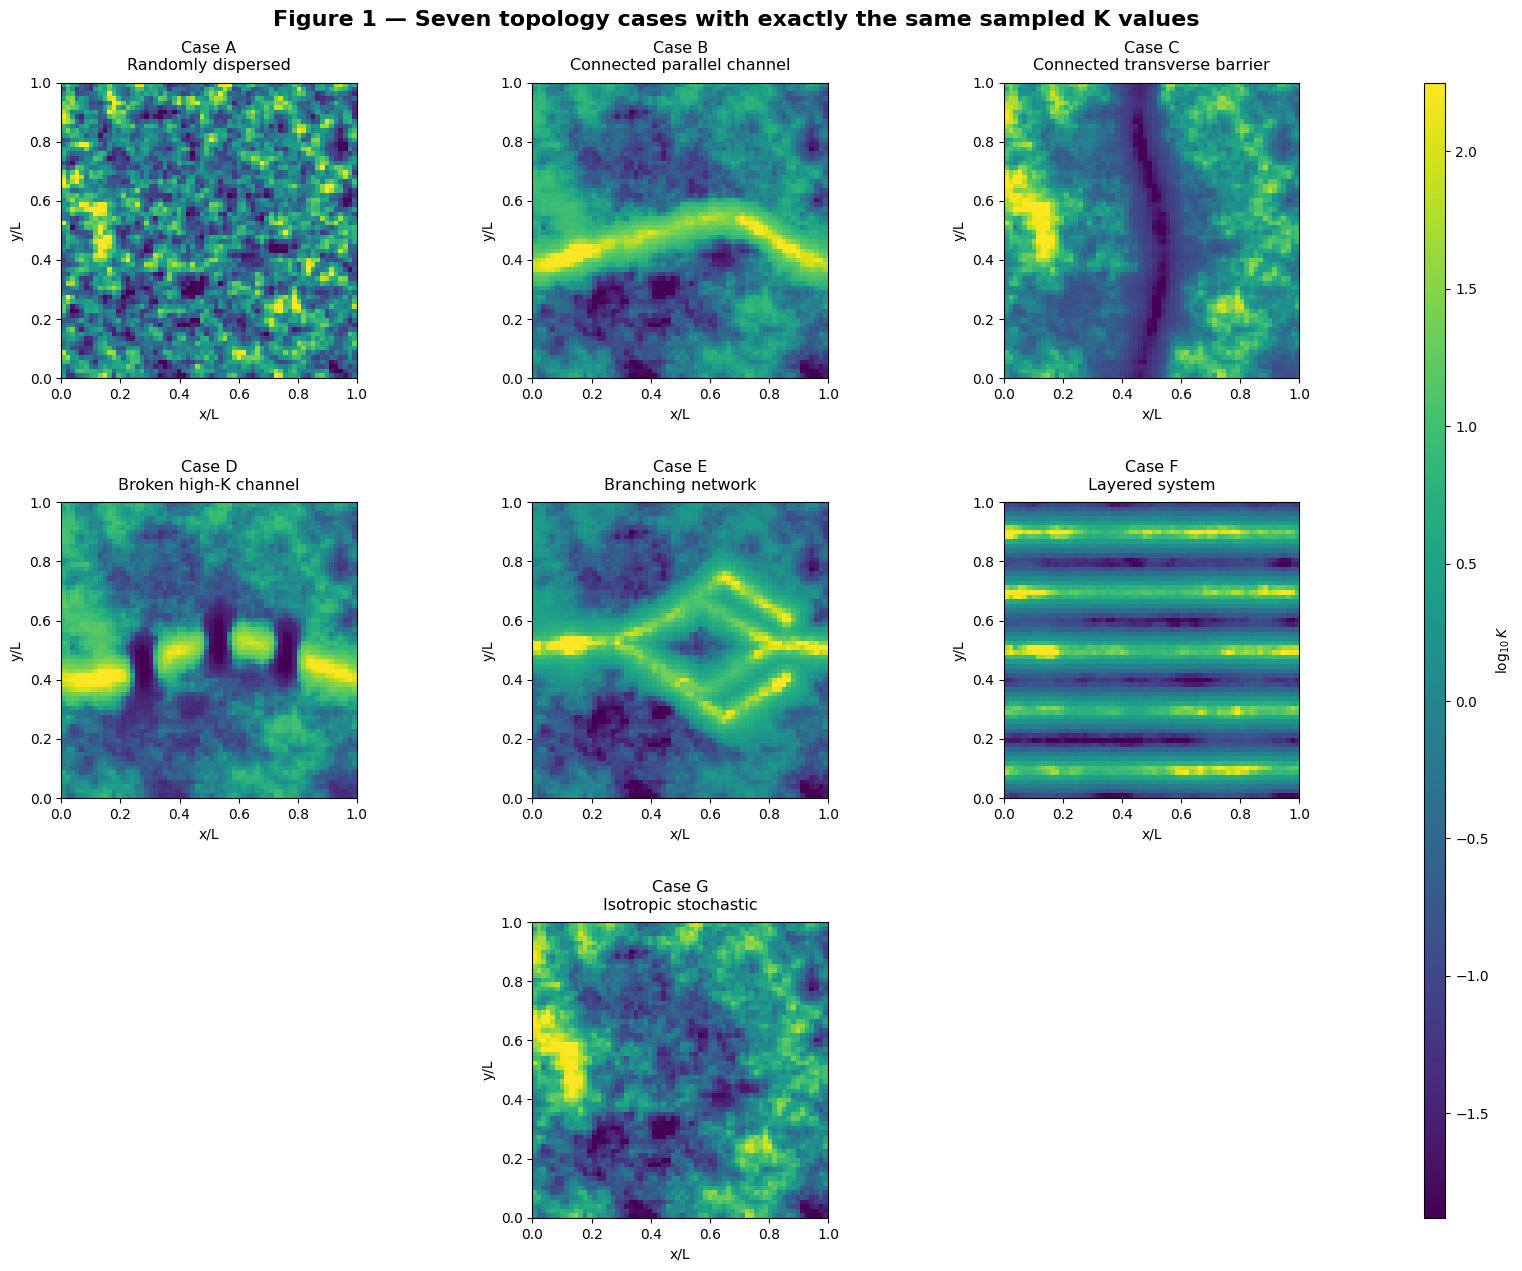

PosixPath('/content/connectivity_seven_case_study/figures/Fig01_seven_topologies.png')

In [4]:

def savefig(fig,name,dpi=300):
    p=FIG_DIR/name
    fig.savefig(p,dpi=dpi,bbox_inches='tight')
    return p

def case_panel_title(case, extra=None):
    """Two-line case title to prevent horizontal overlap."""
    title = f"Case {case}\n{CASE_NAMES[case]}"
    if extra is not None and str(extra).strip():
        title += f"\n{extra}"
    return title


def seven_case_layout(title, with_colorbar=True, figsize=(19.0,9.8)):
    """
    Professional 4-3 layout:
      row 1: A B C D
      row 2:   E F G

    The second row is centered beneath the first row.
    A dedicated colorbar column is added when requested.
    """
    fig = plt.figure(figsize=figsize)

    # Eight equal plotting columns allow four equal-width panels
    # in row 1 and three centered equal-width panels in row 2.
    if with_colorbar:
        gs = fig.add_gridspec(
            2, 9,
            width_ratios=[1,1,1,1,1,1,1,1,0.10],
            height_ratios=[1,1],
            left=0.05, right=0.94, bottom=0.08,
            top=0.86 if str(title).strip() else 0.96,
            wspace=0.36, hspace=0.42
        )
        cax = fig.add_subplot(gs[:,8])
    else:
        gs = fig.add_gridspec(
            2, 8,
            width_ratios=[1,1,1,1,1,1,1,1],
            height_ratios=[1,1],
            left=0.05, right=0.97, bottom=0.08,
            top=0.86 if str(title).strip() else 0.96,
            wspace=0.36, hspace=0.42
        )
        cax = None

    # Row 1: four equal panels.
    # Row 2: three equal panels centered using a one-column offset.
    positions = [
        (0, slice(0,2)),  # A
        (0, slice(2,4)),  # B
        (0, slice(4,6)),  # C
        (0, slice(6,8)),  # D
        (1, slice(1,3)),  # E
        (1, slice(3,5)),  # F
        (1, slice(5,7)),  # G
    ]

    axes = [fig.add_subplot(gs[r,c]) for r,c in positions]

    if str(title).strip():
        fig.suptitle(
            title,
            fontsize=16,
            fontweight='semibold',
            y=0.985
        )

    return fig, axes, cax

EXAMPLE_SIGMA2=4.0
EXAMPLE_LAMBDA=0.10
example_Y,example_K,example_scores=make_suite(
    NX,NY,Lx,Ly,EXAMPLE_LAMBDA,EXAMPLE_SIGMA2,
    MASTER_SEED+17,PAD_FACTOR
)

# ---------------- Figure 1 ----------------
fig,axes,cax = seven_case_layout(
    'Figure 1 — Seven topology cases with exactly the same sampled K values',
    with_colorbar=True,
    figsize=(19.0,9.8)
)

vals=np.concatenate([np.log10(example_K[c]).ravel() for c in CASE_ORDER])
vmin,vmax=np.quantile(vals,[0.01,0.99])

for ax,c in zip(axes,CASE_ORDER):
    im=ax.imshow(
        np.log10(example_K[c]),
        origin='lower',
        extent=[0,1,0,1],
        vmin=vmin,vmax=vmax,
        aspect='equal'
    )
    ax.set_title(case_panel_title(c), fontsize=11.5, pad=9)
    ax.set_xlabel('x/L')
    ax.set_ylabel('y/L')

fig.colorbar(im,cax=cax,label='$\\log_{10}K$')
plt.show()
savefig(fig,'Fig01_seven_topologies.png')


# 9. Figures 2–3 — histogram identity and directional semivariograms

,case,name,mean_Y,var_Y,histogram_mismatch_vs_G,variogram_RMSE_vs_G
0,A,Randomly dispersed,0.000000e+00,4.0,0.0,0.447171
1,B,Connected parallel channel,6.245005e-17,4.0,0.0,0.172120
2,C,Connected transverse barrier,0.000000e+00,4.0,0.0,0.120704
3,D,Broken high-K channel,2.775558e-17,4.0,0.0,0.153103
4,E,Branching network,0.000000e+00,4.0,0.0,0.133451
5,F,Layered system,-1.387779e-17,4.0,0.0,0.743562
6,G,Isotropic stochastic,0.000000e+00,4.0,0.0,0.000000


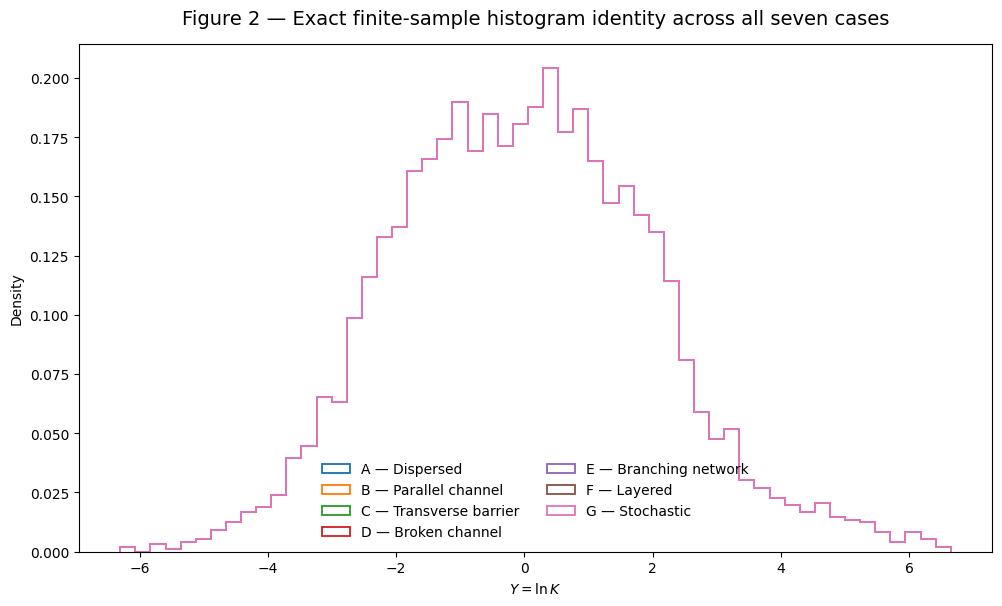

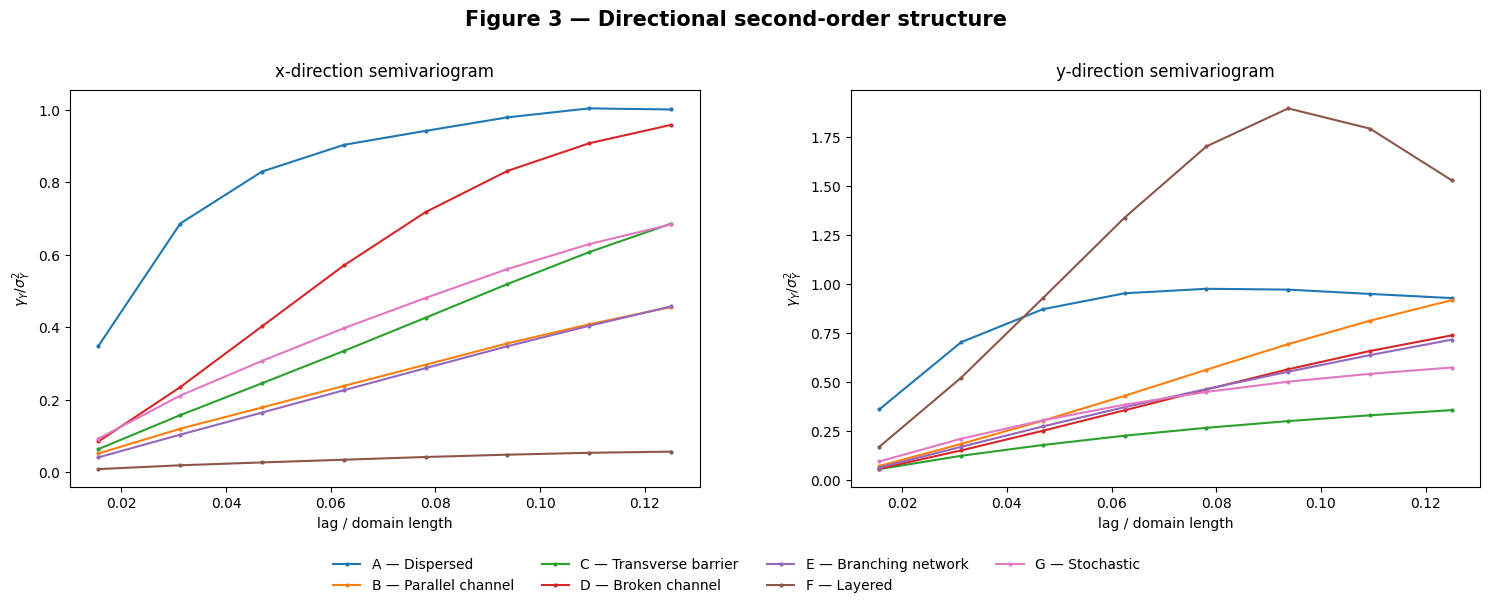

PosixPath('/content/connectivity_seven_case_study/figures/Fig03_directional_semivariograms.png')

In [5]:
# Defensive label definitions in case this cell is run independently
if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        'A':'Dispersed',
        'B':'Parallel channel',
        'C':'Transverse barrier',
        'D':'Broken channel',
        'E':'Branching network',
        'F':'Layered',
        'G':'Stochastic'
    }


def directional_semivariogram(f,max_lag=None):
    f=np.asarray(f,float)
    ny,nx=f.shape
    if max_lag is None:
        max_lag=max(3,min(nx,ny)//8)
    max_lag=min(max_lag,nx-1,ny-1)
    gx=[]; gy=[]
    for lag in range(1,max_lag+1):
        dx=f[:,lag:]-f[:,:-lag]
        dy=f[lag:,:]-f[:-lag,:]
        gx.append(0.5*np.mean(dx*dx))
        gy.append(0.5*np.mean(dy*dy))
    return np.arange(1,max_lag+1),np.array(gx),np.array(gy)

def histogram_mismatch(ref,test):
    return float(np.max(np.abs(
        np.sort(ref.ravel())-np.sort(test.ravel())
    )))

def variogram_rmse(ref,test,max_lag=None):
    _,rx,ry=directional_semivariogram(ref,max_lag)
    _,tx,ty=directional_semivariogram(test,max_lag)
    v=max(np.var(ref),1e-15)
    return float(np.sqrt(np.mean(np.r_[
        ((tx-rx)/v)**2,
        ((ty-ry)/v)**2
    ])))

diag=[]
for c in CASE_ORDER:
    diag.append({
        'case':c,
        'name':CASE_NAMES[c],
        'mean_Y':example_Y[c].mean(),
        'var_Y':example_Y[c].var(),
        'histogram_mismatch_vs_G':
            histogram_mismatch(example_Y['G'],example_Y[c]),
        'variogram_RMSE_vs_G':
            0.0 if c=='G' else variogram_rmse(example_Y['G'],example_Y[c])
    })
diag=pd.DataFrame(diag)
display(diag)

# ---------------- Figure 2 ----------------
fig,ax=plt.subplots(figsize=(10.5,6.6))
for c in CASE_ORDER:
    ax.hist(
        example_Y[c].ravel(),
        bins=55,density=True,
        histtype='step',linewidth=1.35,
        label=f'{c} — {CASE_SHORT[c]}'
    )
ax.set_xlabel('$Y=\\ln K$')
ax.set_ylabel('Density')
ax.set_title(
    'Figure 2 — Exact finite-sample histogram identity across all seven cases',
    fontsize=14,pad=14
)
ax.legend(ncol=2,frameon=False)
fig.subplots_adjust(left=0.10,right=0.97,bottom=0.11,top=0.88)
plt.show()
savefig(fig,'Fig02_histogram_identity.png')

# ---------------- Figure 3 ----------------
fig,axes=plt.subplots(1,2,figsize=(15.5,6.2))
ml=max(4,min(NX,NY)//8)

for c in CASE_ORDER:
    lag,gx,gy=directional_semivariogram(example_Y[c],ml)
    v=np.var(example_Y[c])
    axes[0].plot(lag/NX,gx/v,marker='o',ms=2,label=f'{c} — {CASE_SHORT[c]}')
    axes[1].plot(lag/NY,gy/v,marker='o',ms=2,label=f'{c} — {CASE_SHORT[c]}')

for ax,t in zip(axes,['x-direction semivariogram','y-direction semivariogram']):
    ax.set_xlabel('lag / domain length')
    ax.set_ylabel('$\\gamma_Y/\\sigma_Y^2$')
    ax.set_title(t,fontsize=12,pad=10)

handles,labels_=axes[0].get_legend_handles_labels()
fig.legend(
    handles,labels_,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.01)
)
fig.suptitle(
    'Figure 3 — Directional second-order structure',
    fontsize=15,fontweight='semibold',y=0.97
)
fig.subplots_adjust(left=0.07,right=0.98,bottom=0.20,top=0.84,wspace=0.24)
plt.show()
savefig(fig,'Fig03_directional_semivariograms.png')


# 10. Cell-centered finite-volume groundwater solver

In [6]:
@dataclass
class FlowResult:
    h:np.ndarray; qx_face:np.ndarray; qy_face:np.ndarray; qx_cell:np.ndarray; qy_cell:np.ndarray
    qmag:np.ndarray; gradmag:np.ndarray; Qin:float; Qout:float; Keff:float; mass_error:float

def harmonic(a,b): return 2*a*b/np.maximum(a+b,1e-300)

def assemble_fvm_x(K,Lx=1.0,Ly=1.0,h_left=1.0,h_right=0.0,thickness=1.0):
    K=np.asarray(K,float); ny,nx=K.shape; dx,dy=Lx/nx,Ly/ny; N=nx*ny
    A=lil_matrix((N,N)); b=np.zeros(N)
    def idx(j,i): return j*nx+i
    for j in range(ny):
        for i in range(nx):
            p=idx(j,i); ap=0.0
            if i==0:
                T=K[j,i]*dy*thickness/(0.5*dx); ap+=T; b[p]+=T*h_left
            else:
                T=harmonic(K[j,i],K[j,i-1])*dy*thickness/dx; ap+=T; A[p,idx(j,i-1)]-=T
            if i==nx-1:
                T=K[j,i]*dy*thickness/(0.5*dx); ap+=T; b[p]+=T*h_right
            else:
                T=harmonic(K[j,i],K[j,i+1])*dy*thickness/dx; ap+=T; A[p,idx(j,i+1)]-=T
            if j>0:
                T=harmonic(K[j,i],K[j-1,i])*dx*thickness/dy; ap+=T; A[p,idx(j-1,i)]-=T
            if j<ny-1:
                T=harmonic(K[j,i],K[j+1,i])*dx*thickness/dy; ap+=T; A[p,idx(j+1,i)]-=T
            A[p,p]+=ap
    return A.tocsr(),b

def solve_fvm_x(K,Lx=1.0,Ly=1.0,h_left=1.0,h_right=0.0,thickness=1.0,solver='direct'):
    K=np.asarray(K,float); ny,nx=K.shape; dx,dy=Lx/nx,Ly/ny
    A,b=assemble_fvm_x(K,Lx,Ly,h_left,h_right,thickness)
    if solver=='direct': hv=spsolve(A,b)
    else:
        M=sparse.diags(1/np.maximum(A.diagonal(),1e-30)); hv,info=cg(A,b,M=M,rtol=1e-10,atol=0,maxiter=max(5000,5*A.shape[0]))
        if info!=0: raise RuntimeError(f'CG failed info={info}')
    h=hv.reshape(ny,nx); qx=np.zeros((ny,nx+1)); qy=np.zeros((ny+1,nx))
    qx[:,0]=-K[:,0]*(h[:,0]-h_left)/(0.5*dx)
    if nx>1: qx[:,1:nx]=-harmonic(K[:,:-1],K[:,1:])*(h[:,1:]-h[:,:-1])/dx
    qx[:,-1]=-K[:,-1]*(h_right-h[:,-1])/(0.5*dx)
    if ny>1: qy[1:ny,:]=-harmonic(K[:-1,:],K[1:,:])*(h[1:,:]-h[:-1,:])/dy
    qxc=0.5*(qx[:,:-1]+qx[:,1:]); qyc=0.5*(qy[:-1,:]+qy[1:,:]); qmag=np.sqrt(qxc*qxc+qyc*qyc)
    dhdy,dhdx=np.gradient(h,dy,dx); gradmag=np.sqrt(dhdx*dhdx+dhdy*dhdy)
    Qin=float(np.sum(qx[:,0])*dy*thickness); Qout=float(np.sum(qx[:,-1])*dy*thickness)
    Keff=float(0.5*(Qin+Qout)*Lx/(Ly*thickness*(h_left-h_right)))
    mass=float(abs(Qin-Qout)/max(abs(Qin),1e-30))
    return FlowResult(h,qx,qy,qxc,qyc,qmag,gradmag,Qin,Qout,Keff,mass)

def directional_keff(K):
    fx=solve_fvm_x(K,Lx,Ly,H_LEFT,H_RIGHT,THICKNESS,SOLVER)
    fy=solve_fvm_x(K.T,Ly,Lx,H_LEFT,H_RIGHT,THICKNESS,SOLVER)
    return fx,fy

# 11. Homogeneous analytical benchmark and mass balance

In [7]:
K0=3.7; Ku=np.full((NY,NX),K0); fx0,fy0=directional_keff(Ku)
benchmark=pd.DataFrame([{'K0':K0,'Kx':fx0.Keff,'Ky':fy0.Keff,
                         'relerr_x':abs(fx0.Keff-K0)/K0,'relerr_y':abs(fy0.Keff-K0)/K0,
                         'mass_x':fx0.mass_error,'mass_y':fy0.mass_error}])
display(benchmark)
assert abs(fx0.Keff-K0)/K0<5e-8 and abs(fy0.Keff-K0)/K0<5e-8
assert fx0.mass_error<1e-8 and fy0.mass_error<1e-8
print('Homogeneous FVM benchmark passed.')

,K0,Kx,Ky,relerr_x,relerr_y,mass_x,mass_y
0,3.7,3.7,3.7,1.272256e-14,1.272256e-14,1.134228e-13,1.134228e-13


Homogeneous FVM benchmark passed.


# 12. Figures 4–5 — head and Darcy-flux response for A–G

A Randomly dispersed Kx= 0.8632356650658115 Ky= 0.8908399878886224 Kx/Ky= 0.9690131525323242
B Connected parallel channel Kx= 4.5033857090771985 Ky= 0.8706894806644894 Kx/Ky= 5.1722064054803125
C Connected transverse barrier Kx= 0.234060057081915 Ky= 1.4781769483514153 Kx/Ky= 0.158343733707225
D Broken high-K channel Kx= 0.5918893827478557 Ky= 1.002038943467178 Kx/Ky= 0.5906850094067659
E Branching network Kx= 3.942846591445213 Ky= 0.7820887924936881 Kx/Ky= 5.04143088264116
F Layered system Kx= 3.935797598538947 Ky= 0.26079130250350663 Kx/Ky= 15.09175175995766
G Isotropic stochastic Kx= 0.760284955261056 Ky= 1.185858065781508 Kx/Ky= 0.6411264359533706


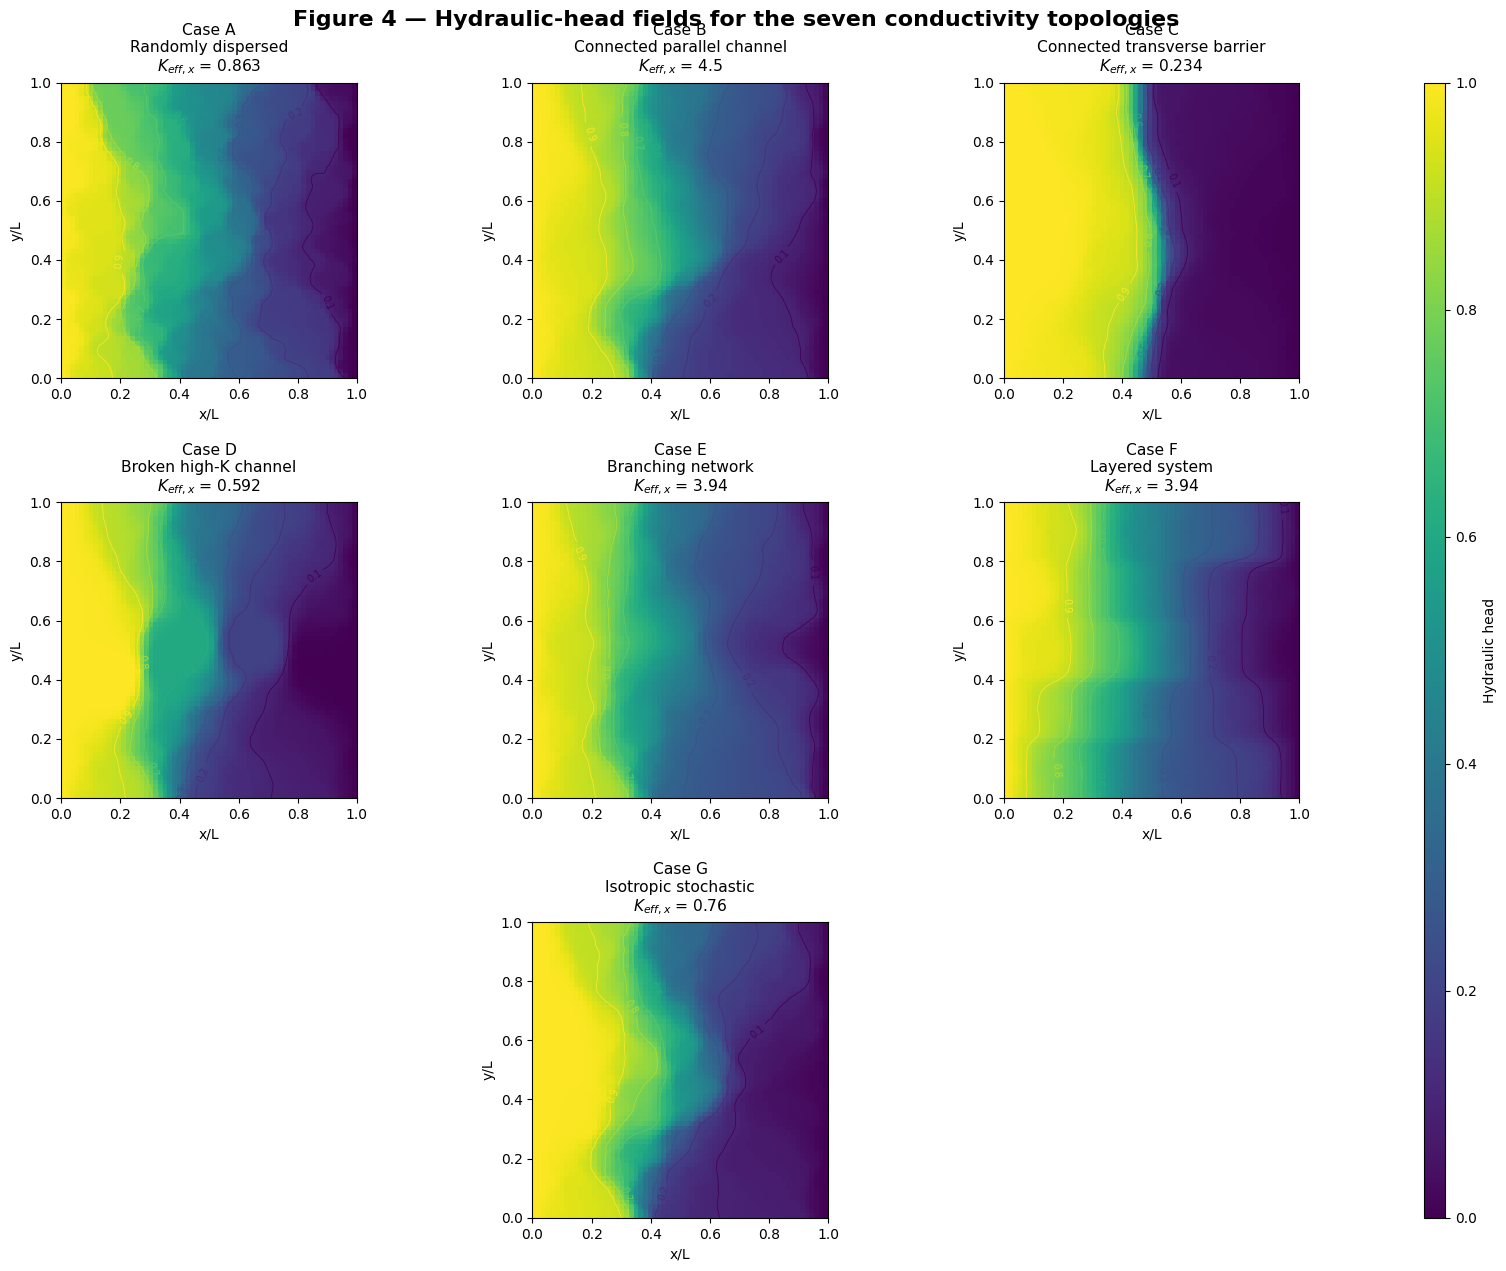

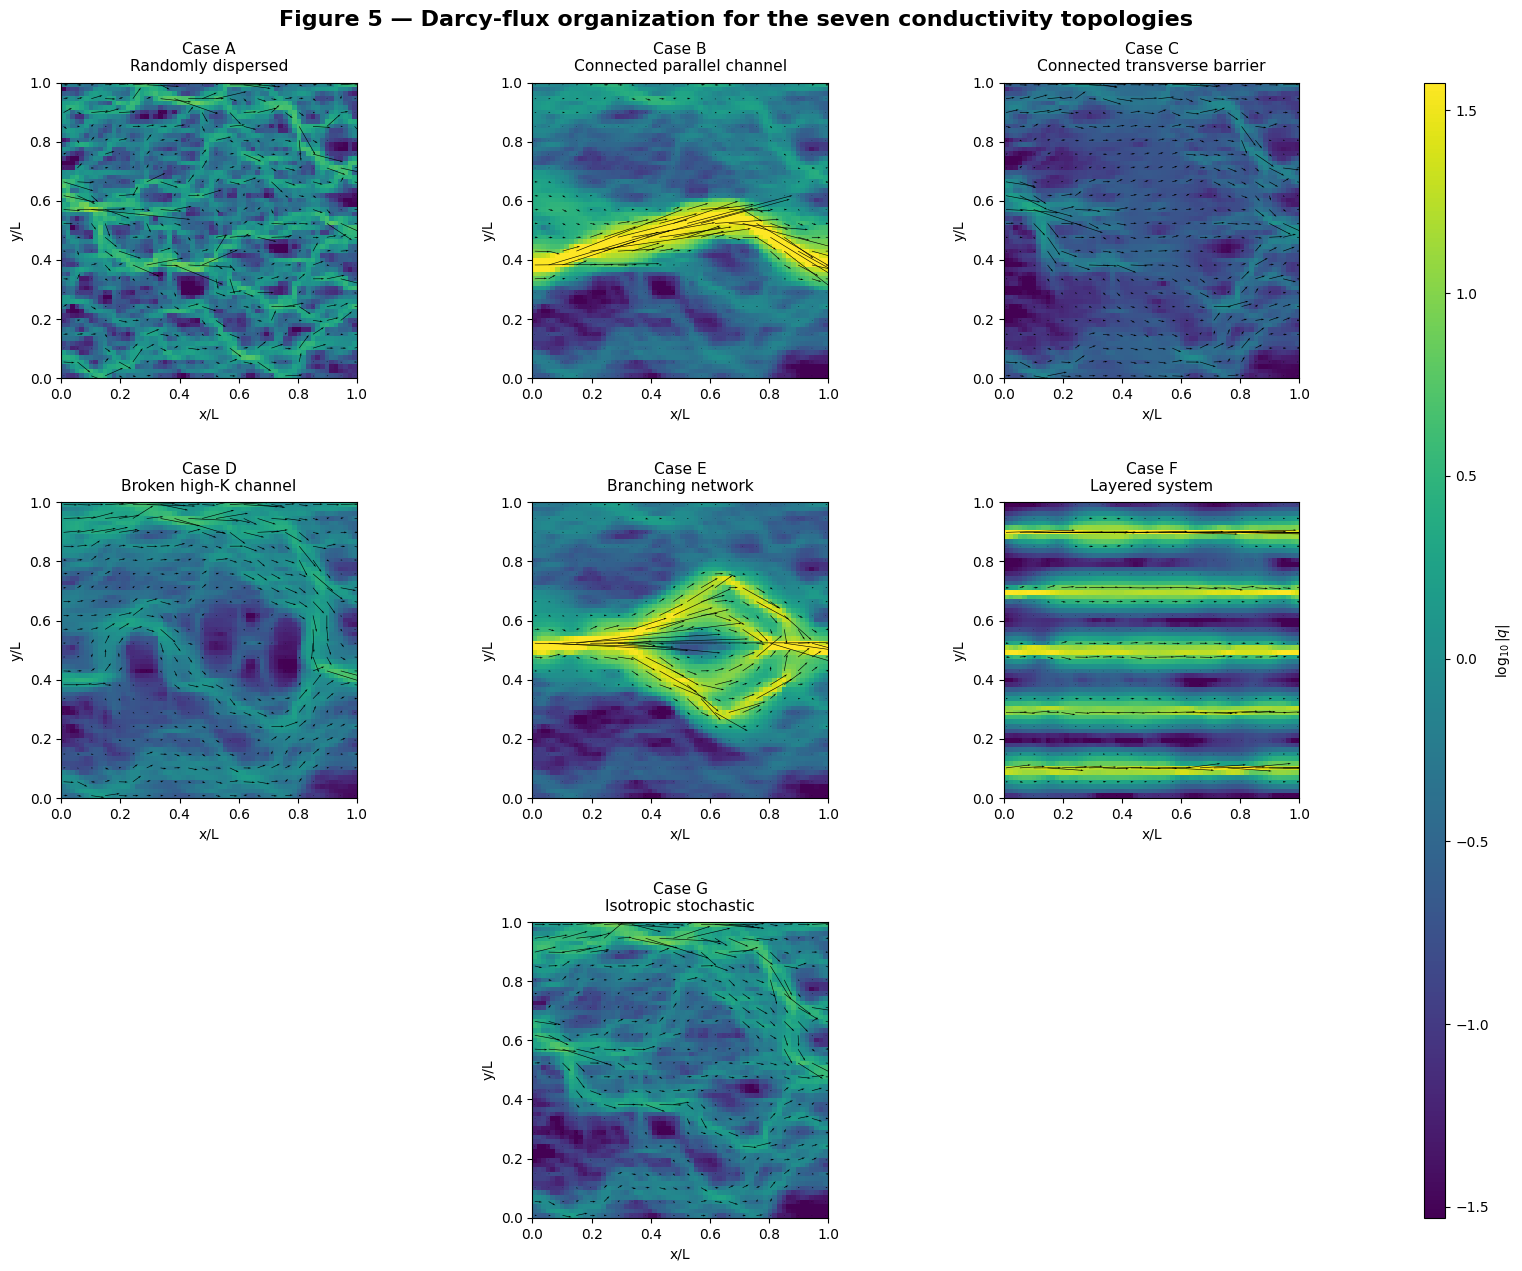

PosixPath('/content/connectivity_seven_case_study/figures/Fig05_flux_fields.png')

In [8]:

example_flow={}
for c in CASE_ORDER:
    fx,fy=directional_keff(example_K[c])
    example_flow[c]=(fx,fy)
    print(
        c,CASE_NAMES[c],
        'Kx=',fx.Keff,
        'Ky=',fy.Keff,
        'Kx/Ky=',fx.Keff/fy.Keff
    )

# ---------------- Figure 4: head ----------------
fig,axes,cax = seven_case_layout(
    'Figure 4 — Hydraulic-head fields for the seven conductivity topologies',
    with_colorbar=True,
    figsize=(19.0,9.8)
)

for ax,c in zip(axes,CASE_ORDER):
    fx,_=example_flow[c]
    im=ax.imshow(
        fx.h,origin='lower',extent=[0,1,0,1],
        vmin=0,vmax=1,aspect='equal'
    )
    cs=ax.contour(
        np.linspace(0,1,NX),
        np.linspace(0,1,NY),
        fx.h,
        levels=np.linspace(.1,.9,9),
        linewidths=.55
    )
    ax.clabel(cs,inline=True,fontsize=7,fmt='%.1f')
    ax.set_title(
        case_panel_title(c,f'$K_{{eff,x}}$ = {fx.Keff:.3g}'),
        fontsize=11.2,pad=8
    )
    ax.set_xlabel('x/L')
    ax.set_ylabel('y/L')

fig.colorbar(im,cax=cax,label='Hydraulic head')
plt.show()
savefig(fig,'Fig04_head_fields.png')

# ---------------- Figure 5: Darcy flux ----------------
lq=np.concatenate([
    np.log10(np.maximum(example_flow[c][0].qmag.ravel(),1e-30))
    for c in CASE_ORDER
])
lo,hi=np.quantile(lq,[.01,.99])

fig,axes,cax = seven_case_layout(
    'Figure 5 — Darcy-flux organization for the seven conductivity topologies',
    with_colorbar=True,
    figsize=(19.0,9.8)
)

xc=(np.arange(NX)+.5)/NX
yc=(np.arange(NY)+.5)/NY
Xc,Yc=np.meshgrid(xc,yc)
st=max(1,NX//18)

for ax,c in zip(axes,CASE_ORDER):
    fx,_=example_flow[c]
    im=ax.imshow(
        np.log10(np.maximum(fx.qmag,1e-30)),
        origin='lower',extent=[0,1,0,1],
        vmin=lo,vmax=hi,aspect='equal'
    )
    ax.quiver(
        Xc[::st,::st],Yc[::st,::st],
        fx.qx_cell[::st,::st],
        fx.qy_cell[::st,::st],
        width=.002
    )
    ax.set_title(case_panel_title(c),fontsize=11.2,pad=8)
    ax.set_xlabel('x/L')
    ax.set_ylabel('y/L')

fig.colorbar(im,cax=cax,label='$\\log_{10}|q|$')
plt.show()
savefig(fig,'Fig05_flux_fields.png')


# 13. Directional percolation and minimum-resistance metrics

In [9]:
CONNECTIVITY4=np.array([[0,1,0],[1,1,1],[0,1,0]],int)
def spanning_labels(mask,direction='x'):
    lab,n=label(mask,structure=CONNECTIVITY4)
    if n==0: return set(),lab
    if direction=='x': a=set(np.unique(lab[:,0])); b=set(np.unique(lab[:,-1]))
    else: a=set(np.unique(lab[0,:])); b=set(np.unique(lab[-1,:]))
    return (a&b)-{0},lab

def spanning_fraction(field,q,mode='high',direction='x'):
    th=np.quantile(field,q) if mode=='high' else np.quantile(field,1-q)
    mask=field>=th if mode=='high' else field<=th
    labs,lab=spanning_labels(mask,direction); nt=mask.sum()
    if nt==0 or not labs: return 0.0,False,mask,lab
    sm=np.isin(lab,list(labs)); return float(sm.sum()/nt),True,mask,lab

def critical_spanning_quantile(field,mode='high',direction='x',qmin=.50,qmax=.995,nq=100):
    qc=np.nan; tc=np.nan
    for q in np.linspace(qmin,qmax,nq):
        _,sp,_,_=spanning_fraction(field,q,mode,direction)
        if sp: qc=q; tc=np.quantile(field,q) if mode=='high' else np.quantile(field,1-q)
    return (0.0 if not np.isfinite(qc) else qc),tc

def integrated_spanning_fraction(field,mode='high',direction='x',q1=.50,q2=.95,nq=20):
    qs=np.linspace(q1,q2,nq); vals=[spanning_fraction(field,q,mode,direction)[0] for q in qs]
    return float(np.trapz(vals,qs)/(q2-q1))

def minimum_path_resistance_x(K,Lx=1.0,Ly=1.0):
    K=np.asarray(K,float); ny,nx=K.shape; dx,dy=Lx/nx,Ly/ny; dist=np.full((ny,nx),np.inf); heap=[]
    for j in range(ny):
        d0=.5*dx/max(K[j,0],1e-300); dist[j,0]=d0; heapq.heappush(heap,(d0,j,0))
    forpop=[(0,-1,dx),(0,1,dx),(-1,0,dy),(1,0,dy)]
    while heap:
        d,j,i=heapq.heappop(heap)
        if d!=dist[j,i]: continue
        if i==nx-1: return float(d+.5*dx/max(K[j,i],1e-300))
        for dj,di,ds in forpop:
            jj,ii=j+dj,i+di
            if 0<=jj<ny and 0<=ii<nx:
                nd=d+ds/max(harmonic(K[j,i],K[jj,ii]),1e-300)
                if nd<dist[jj,ii]: dist[jj,ii]=nd; heapq.heappush(heap,(nd,jj,ii))
    return np.nan

def connectivity_metrics(Y,K,kg=1.0):
    out={}
    for d in ['x','y']:
        for m in ['high','low']:
            qc,yc=critical_spanning_quantile(Y,m,d); cs=integrated_spanning_fraction(Y,m,d)
            out[f'qcrit_{m}_{d}']=qc; out[f'Ycrit_{m}_{d}']=yc; out[f'Cspan_{m}_{d}']=cs
    if CALCULATE_PATH_RESISTANCE:
        rx=minimum_path_resistance_x(K,Lx,Ly); ry=minimum_path_resistance_x(K.T,Ly,Lx)
        out.update({'Rmin_x':rx,'Rmin_y':ry,'C_R_x':(Lx/kg)/rx,'C_R_y':(Ly/kg)/ry,'C_R_ratio_xy':((Lx/kg)/rx)/((Ly/kg)/ry)})
    else:
        out.update({'Rmin_x':np.nan,'Rmin_y':np.nan,'C_R_x':np.nan,'C_R_y':np.nan,'C_R_ratio_xy':np.nan})
    return out

ce=[]
for c in CASE_ORDER:
    r={'case':c}; r.update(connectivity_metrics(example_Y[c],example_K[c],1.0)); ce.append(r)
display(pd.DataFrame(ce))

/tmp/ipykernel_2090/809627458.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals,qs)/(q2-q1))


,case,qcrit_high_x,Ycrit_high_x,Cspan_high_x,qcrit_low_x,Ycrit_low_x,Cspan_low_x,qcrit_high_y,Ycrit_high_y,Cspan_high_y,qcrit_low_y,Ycrit_low_y,Cspan_low_y,Rmin_x,Rmin_y,C_R_x,C_R_y,C_R_ratio_xy
0,A,0.000,NaN,0.000000,0.000,NaN,0.000000,0.000,NaN,0.000000,0.000,NaN,0.000000,0.337676,0.237728,2.961414,4.206494,0.704010
1,B,0.945,3.217614,0.813259,0.000,NaN,0.000000,0.575,0.362850,0.162451,0.000,NaN,0.000000,0.015545,0.286484,64.328255,3.490602,18.428987
2,C,0.000,NaN,0.000000,0.000,NaN,0.000000,0.710,1.094344,0.263721,0.940,-2.977356,0.879952,2.064149,0.148913,0.484461,6.715350,0.072142
3,D,0.000,NaN,0.000000,0.000,NaN,0.000000,0.610,0.539024,0.112752,0.545,-0.260250,0.110465,0.390080,0.244819,2.563576,4.084648,0.627612
4,E,0.880,2.275358,0.826781,0.500,-0.034684,0.014160,0.000,NaN,0.000000,0.000,NaN,0.000000,0.038288,0.401938,26.117711,2.487947,10.497694
5,F,0.850,2.040641,0.715293,0.845,-2.056296,0.699202,0.000,NaN,0.000000,0.000,NaN,0.000000,0.035002,1.984881,28.569696,0.503808,56.707451
6,G,0.000,NaN,0.000000,0.000,NaN,0.000000,0.695,1.009779,0.237478,0.525,-0.165863,0.066103,0.234179,0.157204,4.270229,6.361163,0.671297


# 14. Figure 6 — thresholded high-\(K\) spanning structures

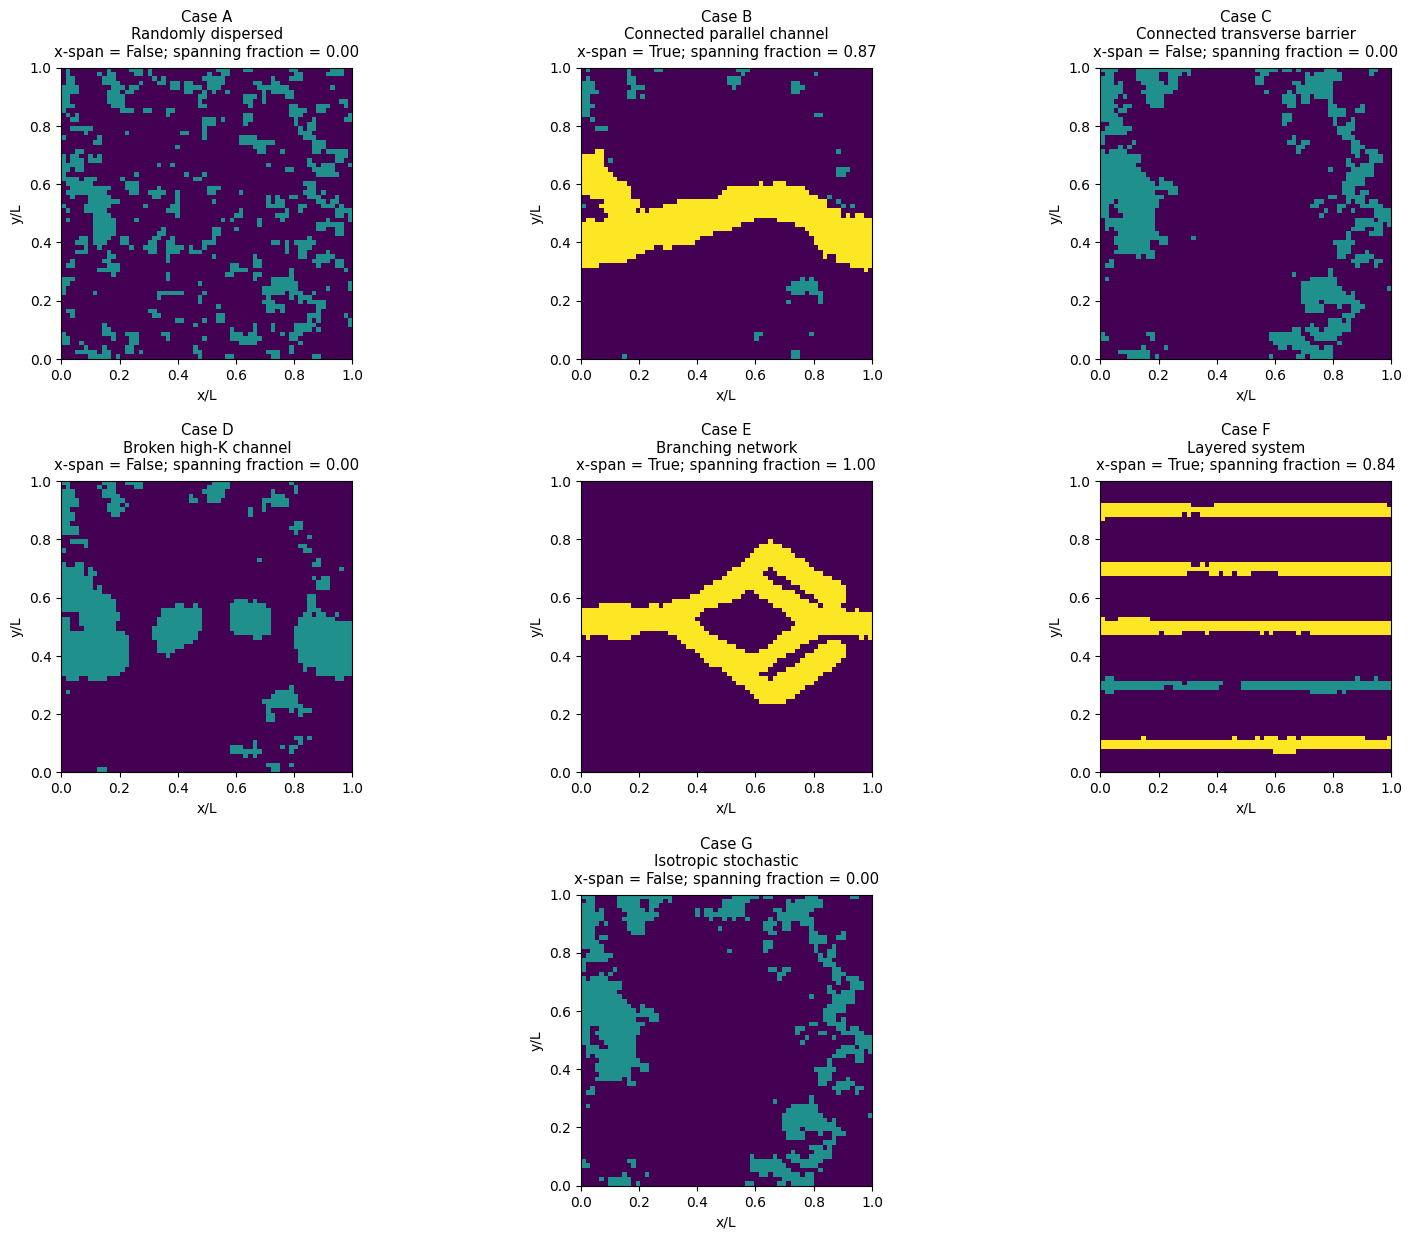

PosixPath('/content/connectivity_seven_case_study/figures/Fig06_threshold_connectivity.png')

In [32]:

QVIEW=.80

fig,axes,_ = seven_case_layout(
    f'',
    with_colorbar=False,
    figsize=(19.0,9.6)
)

for ax,c in zip(axes,CASE_ORDER):
    frac,sp,mask,lab=spanning_fraction(
        example_Y[c],QVIEW,'high','x'
    )
    labs,_=spanning_labels(mask,'x')
    spanmask=np.isin(lab,list(labs)) if labs else np.zeros_like(mask)

    view=np.zeros_like(mask,float)
    view[mask]=1
    view[spanmask]=2

    ax.imshow(
        view,origin='lower',extent=[0,1,0,1],
        vmin=0,vmax=2,aspect='equal'
    )
    ax.set_title(
        case_panel_title(
            c,
            f'x-span = {sp}; spanning fraction = {frac:.2f}'
        ),
        fontsize=10.7,pad=8
    )
    ax.set_xlabel('x/L')
    ax.set_ylabel('y/L')

plt.show()
savefig(fig,'Fig06_threshold_connectivity.png')


# 15. Flux and gradient localization metrics

In [11]:
def top_share(values,f=.10):
    v=np.asarray(values,float).ravel(); v=v[np.isfinite(v)]; v=np.maximum(v,0)
    if len(v)==0 or v.sum()==0:return np.nan
    n=max(1,int(np.ceil(f*len(v)))); return float(np.sort(v)[-n:].sum()/v.sum())

def gini(values):
    x=np.asarray(values,float).ravel(); x=x[np.isfinite(x)]; x=np.maximum(x,0)
    if len(x)==0 or np.allclose(x.sum(),0):return np.nan
    x=np.sort(x); n=len(x); cx=np.cumsum(x); return float((n+1-2*np.sum(cx)/cx[-1])/n)

def hydraulic_metrics(flow):
    return {'F10_flux':top_share(flow.qmag,.10),'Gini_flux':gini(flow.qmag),'G10_gradient':top_share(flow.gradmag,.10),
            'head_std':float(flow.h.std()),'qmean':float(flow.qmag.mean()),'qmax':float(flow.qmag.max())}

er=[]
for c in CASE_ORDER:
    fx,fy=example_flow[c]; r={'case':c,'Keff_x':fx.Keff,'Keff_y':fy.Keff,'Kx_over_Ky':fx.Keff/fy.Keff}; r.update(hydraulic_metrics(fx)); er.append(r)
display(pd.DataFrame(er))

,case,Keff_x,Keff_y,Kx_over_Ky,F10_flux,Gini_flux,G10_gradient,head_std,qmean,qmax
0,A,0.863236,0.890840,0.969013,0.360676,0.519169,0.300329,0.321444,0.997785,13.893402
1,B,4.503386,0.870689,5.172206,0.816735,0.845970,0.306214,0.343887,4.757823,123.261750
2,C,0.234060,1.478177,0.158344,0.280388,0.375907,0.696712,0.450972,0.255984,2.578156
3,D,0.591889,1.002039,0.590685,0.334156,0.476591,0.378053,0.368081,0.682169,5.565810
4,E,3.942847,0.782089,5.041431,0.683397,0.802588,0.263438,0.318230,4.291654,135.789365
5,F,3.935798,0.260791,15.091752,0.577382,0.744213,0.197609,0.327340,3.957691,53.064032
6,G,0.760285,1.185858,0.641126,0.386131,0.530534,0.370843,0.378882,0.859418,8.562750


# 16. Paired A–G Monte-Carlo realization engine

In [12]:
def run_one_realization(sigma2,lambda_rel,rid,nx=NX,ny=NY):
    seed=int(MASTER_SEED+100000*round(100*lambda_rel)+1000*round(100*sigma2)+rid)
    Y,K,_=make_suite(nx,ny,Lx,Ly,lambda_rel,sigma2,seed,PAD_FACTOR); means=classical_means(MU_Y,sigma2); rows=[]
    for c in CASE_ORDER:
        fx=solve_fvm_x(K[c],Lx,Ly,H_LEFT,H_RIGHT,THICKNESS,SOLVER)
        fy=solve_fvm_x(K[c].T,Ly,Lx,H_LEFT,H_RIGHT,THICKNESS,SOLVER) if RUN_DIRECTIONAL_Y else None
        conn=connectivity_metrics(Y[c],K[c],means['K_G']); hyd=hydraulic_metrics(fx); Ky=fy.Keff if fy else np.nan
        row={'sigma2':sigma2,'lambda_parent_rel':lambda_rel,'realization':rid,'seed':seed,'case':c,'case_name':CASE_NAMES[c],
             'Keff_x':fx.Keff,'Keff_y':Ky,'Kx_over_Ky':fx.Keff/Ky if np.isfinite(Ky) else np.nan,
             'ln_Kx_over_KG':np.log(fx.Keff/means['K_G']),'mass_error_x':fx.mass_error,'mass_error_y':fy.mass_error if fy else np.nan,
             'mean_Y':Y[c].mean(),'var_Y':Y[c].var(),'histogram_mismatch_vs_G':histogram_mismatch(Y['G'],Y[c]),
             'variogram_RMSE_vs_G':0.0 if c=='G' else variogram_rmse(Y['G'],Y[c],max_lag=max(3,min(nx,ny)//10)),**means,**conn,**hyd}
        rows.append(row)
    kx={r['case']:r['Keff_x'] for r in rows}
    for r in rows:
        r['delta_B_vs_G']=np.log(kx['B']/kx['G']); r['delta_C_vs_G']=np.log(kx['C']/kx['G']); r['delta_D_vs_B']=np.log(kx['D']/kx['B'])
        r['delta_E_vs_G']=np.log(kx['E']/kx['G']); r['delta_F_vs_G']=np.log(kx['F']/kx['G'])
    return rows

# 17. Ensemble execution with checkpointing

In [13]:
MASTER_RESULTS=DATA_DIR/f'ensemble_A_to_G_{RUN_MODE.lower()}.csv'
def run_ensemble():
    allrows=[]; t=time.time(); total=len(SIGMA2_VALUES)*len(LAMBDA_REL_VALUES); ic=0
    for s2 in SIGMA2_VALUES:
        for lam in LAMBDA_REL_VALUES:
            ic+=1; cond=[]; t0=time.time(); print(f'Condition {ic}/{total}: sigma2={s2}, lambda/L={lam}')
            for r in range(N_REALIZATIONS):
                cond.extend(run_one_realization(s2,lam,r))
                if (r+1)%max(1,N_REALIZATIONS//4)==0: print(' ',r+1,'/',N_REALIZATIONS)
            cdf=pd.DataFrame(cond); allrows.extend(cond)
            if SAVE_EVERY_CONDITION: cdf.to_csv(DATA_DIR/f'condition_sigma2_{s2:g}_lambda_{lam:g}.csv',index=False)
            pd.DataFrame(allrows).to_csv(MASTER_RESULTS,index=False); print(' elapsed',time.time()-t0,'s')
    print('Total min:',(time.time()-t)/60); return pd.DataFrame(allrows)

FORCE_RERUN=not MASTER_RESULTS.exists()
results=run_ensemble() if FORCE_RERUN else pd.read_csv(MASTER_RESULTS)
print('Rows:',len(results)); display(results.head())

Condition 1/4: sigma2=0.25, lambda/L=0.05


/tmp/ipykernel_2090/809627458.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals,qs)/(q2-q1))


  1 / 2
  2 / 2
 elapsed 10.066430807113647 s
Condition 2/4: sigma2=0.25, lambda/L=0.2
  1 / 2
  2 / 2
 elapsed 11.70842456817627 s
Condition 3/4: sigma2=6.0, lambda/L=0.05
  1 / 2
  2 / 2
 elapsed 11.73307204246521 s
Condition 4/4: sigma2=6.0, lambda/L=0.2
  1 / 2
  2 / 2
 elapsed 9.80103850364685 s
Total min: 0.7218201677004497
Rows: 56


,sigma2,lambda_parent_rel,realization,seed,case,case_name,Keff_x,Keff_y,Kx_over_Ky,ln_Kx_over_KG,...,Gini_flux,G10_gradient,head_std,qmean,qmax,delta_B_vs_G,delta_C_vs_G,delta_D_vs_B,delta_E_vs_G,delta_F_vs_G
0,0.25,0.05,0,20785901,A,Randomly dispersed,0.979332,0.981988,0.997296,-0.020884,...,0.152696,0.137698,0.287148,0.987083,2.311679,0.057693,-0.069114,-0.09364,0.051407,0.11223
1,0.25,0.05,0,20785901,B,Connected parallel channel,1.063163,0.956152,1.111919,0.061249,...,0.236912,0.139268,0.284230,1.072778,3.803825,0.057693,-0.069114,-0.09364,0.051407,0.11223
2,0.25,0.05,0,20785901,C,Connected transverse barrier,0.936544,1.032272,0.907266,-0.065558,...,0.129701,0.219728,0.312515,0.942927,1.903952,0.057693,-0.069114,-0.09364,0.051407,0.11223
3,0.25,0.05,0,20785901,D,Broken high-K channel,0.968127,0.995799,0.972212,-0.032391,...,0.149641,0.180288,0.295959,0.980514,2.555773,0.057693,-0.069114,-0.09364,0.051407,0.11223
4,0.25,0.05,0,20785901,E,Branching network,1.056501,0.952818,1.108817,0.054962,...,0.232240,0.140752,0.275466,1.062545,3.982759,0.057693,-0.069114,-0.09364,0.051407,0.11223


# 18. Numerical and statistical quality control

In [14]:
qc=pd.DataFrame({'metric':['rows','max mass error x','max mass error y','max histogram mismatch','max |meanY|','max |varY-sigma2|','median non-G variogram mismatch','max non-G variogram mismatch','bad Kx','bad Ky'],
'value':[len(results),results.mass_error_x.max(),results.mass_error_y.max(),results.histogram_mismatch_vs_G.max(),np.max(np.abs(results.mean_Y)),
         np.max(np.abs(results.var_Y-results.sigma2)),results.loc[results.case!='G','variogram_RMSE_vs_G'].median(),results.loc[results.case!='G','variogram_RMSE_vs_G'].max(),
         ((~np.isfinite(results.Keff_x))|(results.Keff_x<=0)).sum(),((~np.isfinite(results.Keff_y))|(results.Keff_y<=0)).sum()]})
display(qc)

,metric,value
0,rows,5.600000e+01
1,max mass error x,4.697311e-11
2,max mass error y,1.803742e-11
3,max histogram mismatch,0.000000e+00
4,max |meanY|,1.526557e-16
5,max |varY-sigma2|,3.552714e-15
6,median non-G variogram mismatch,2.134914e-01
7,max non-G variogram mismatch,7.154124e-01
8,bad Kx,0.000000e+00
9,bad Ky,0.000000e+00


# 19. Figure 7 — longitudinal effective conductivity across A–G

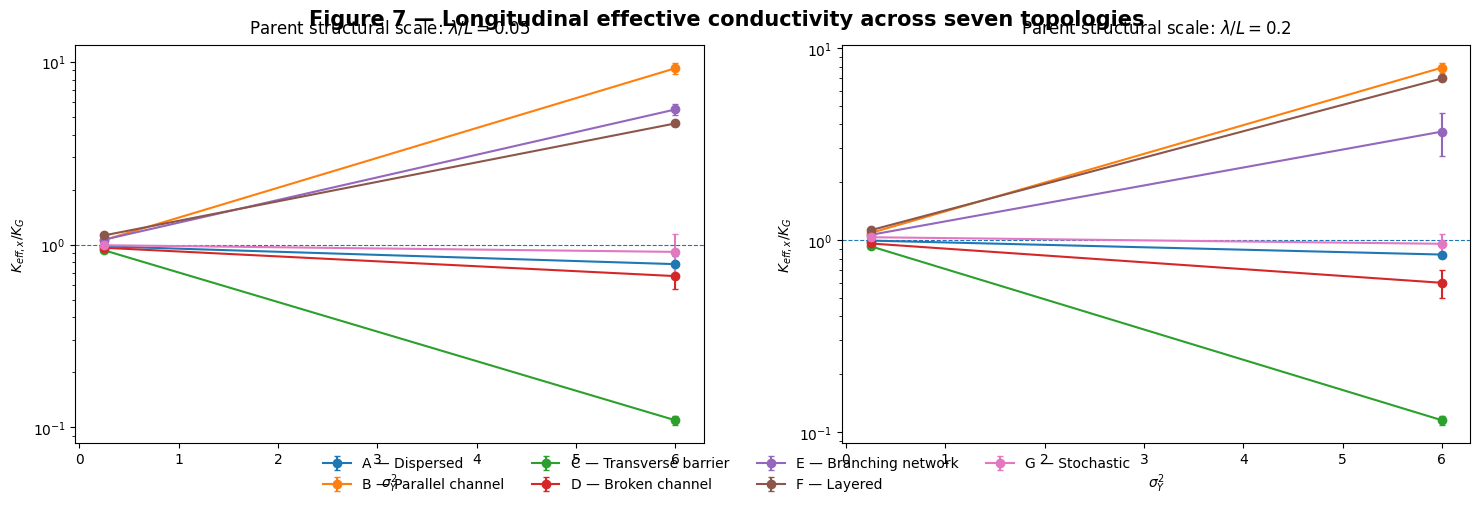

PosixPath('/content/connectivity_seven_case_study/figures/Fig07_Keff_x_vs_variance.png')

In [15]:
# Defensive label definitions in case this cell is run independently
if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        'A':'Dispersed',
        'B':'Parallel channel',
        'C':'Transverse barrier',
        'D':'Broken channel',
        'E':'Branching network',
        'F':'Layered',
        'G':'Stochastic'
    }


summary=results.groupby(
    ['sigma2','lambda_parent_rel','case']
).agg(
    Kx_mean=('Keff_x','mean'),
    Kx_std=('Keff_x','std'),
    Ky_mean=('Keff_y','mean'),
    Ky_std=('Keff_y','std'),
    anis_mean=('Kx_over_Ky','mean'),
    n=('Keff_x','size')
).reset_index()

nlam=len(LAMBDA_REL_VALUES)
nr=int(np.ceil(nlam/2))
fig,axes=plt.subplots(
    nr,2,
    figsize=(15.5,5.1*nr)
)
axes=np.atleast_1d(axes).ravel()

for ax,lam in zip(axes,LAMBDA_REL_VALUES):
    s=summary[np.isclose(summary.lambda_parent_rel,lam)]
    for c in CASE_ORDER:
        d=s[s.case==c].sort_values('sigma2')
        ax.errorbar(
            d.sigma2,d.Kx_mean,yerr=d.Kx_std,
            marker='o',capsize=2,
            label=f'{c} — {CASE_SHORT[c]}'
        )
    ax.axhline(1,linestyle='--',linewidth=.8)
    ax.set_yscale('log')
    ax.set_xlabel('$\\sigma_Y^2$')
    ax.set_ylabel('$K_{eff,x}/K_G$')
    ax.set_title(f'Parent structural scale: $\\lambda/L={lam}$',fontsize=12,pad=9)

for ax in axes[nlam:]:
    ax.axis('off')

handles,labels_=axes[0].get_legend_handles_labels()
fig.legend(
    handles,labels_,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.01)
)
fig.suptitle(
    'Figure 7 — Longitudinal effective conductivity across seven topologies',
    fontsize=15,fontweight='semibold',y=0.98
)
fig.subplots_adjust(left=0.08,right=0.98,bottom=0.13,top=0.91,hspace=0.28,wspace=0.22)
plt.show()
savefig(fig,'Fig07_Keff_x_vs_variance.png')


# 20. Figure 8 — directional anisotropy

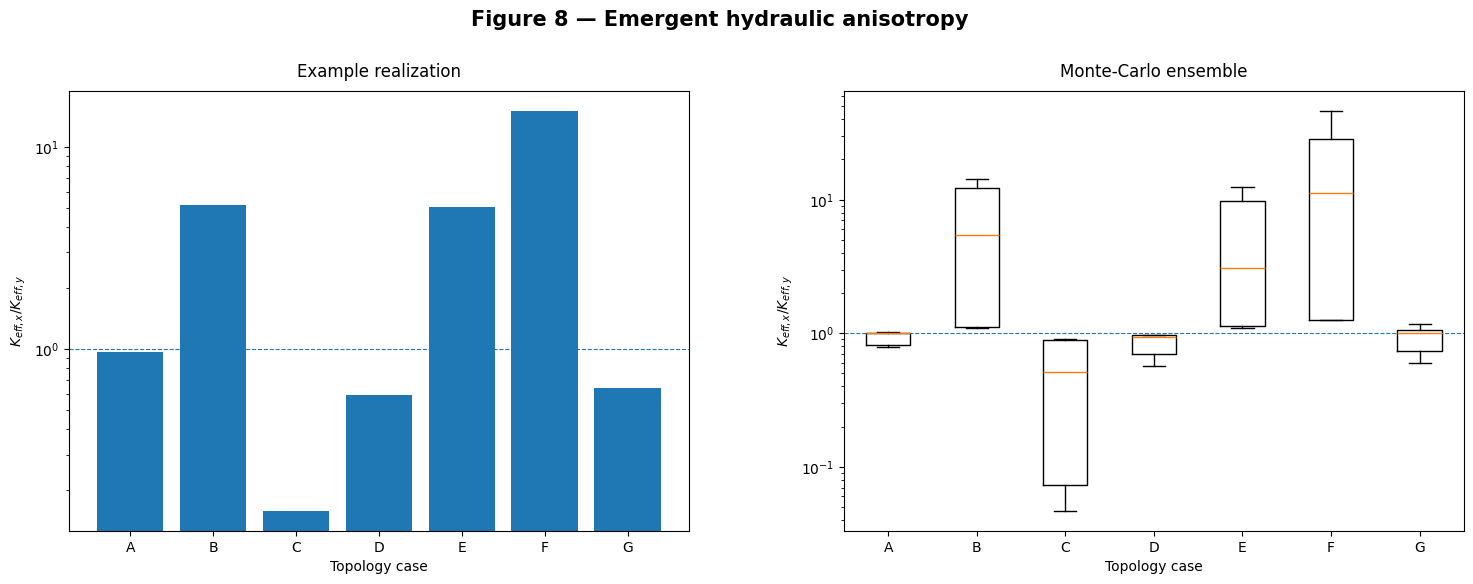

PosixPath('/content/connectivity_seven_case_study/figures/Fig08_anisotropy.png')

In [16]:

fig,axes=plt.subplots(1,2,figsize=(15.5,6.2))

ex=[
    example_flow[c][0].Keff/example_flow[c][1].Keff
    for c in CASE_ORDER
]
axes[0].bar(CASE_ORDER,ex)
axes[0].axhline(1,linestyle='--',linewidth=.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Topology case')
axes[0].set_ylabel('$K_{eff,x}/K_{eff,y}$')
axes[0].set_title('Example realization',fontsize=12,pad=10)

box=[
    results.loc[results.case==c,'Kx_over_Ky'].dropna().values
    for c in CASE_ORDER
]
axes[1].boxplot(box,tick_labels=CASE_ORDER,showfliers=False)
axes[1].axhline(1,linestyle='--',linewidth=.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Topology case')
axes[1].set_ylabel('$K_{eff,x}/K_{eff,y}$')
axes[1].set_title('Monte-Carlo ensemble',fontsize=12,pad=10)

fig.suptitle(
    'Figure 8 — Emergent hydraulic anisotropy',
    fontsize=15,fontweight='semibold',y=0.96
)
fig.subplots_adjust(left=0.08,right=0.98,bottom=0.12,top=0.83,wspace=0.25)
plt.show()
savefig(fig,'Fig08_anisotropy.png')


# 21. Figure 9 — connectivity descriptors versus \(K_{eff,x}\)

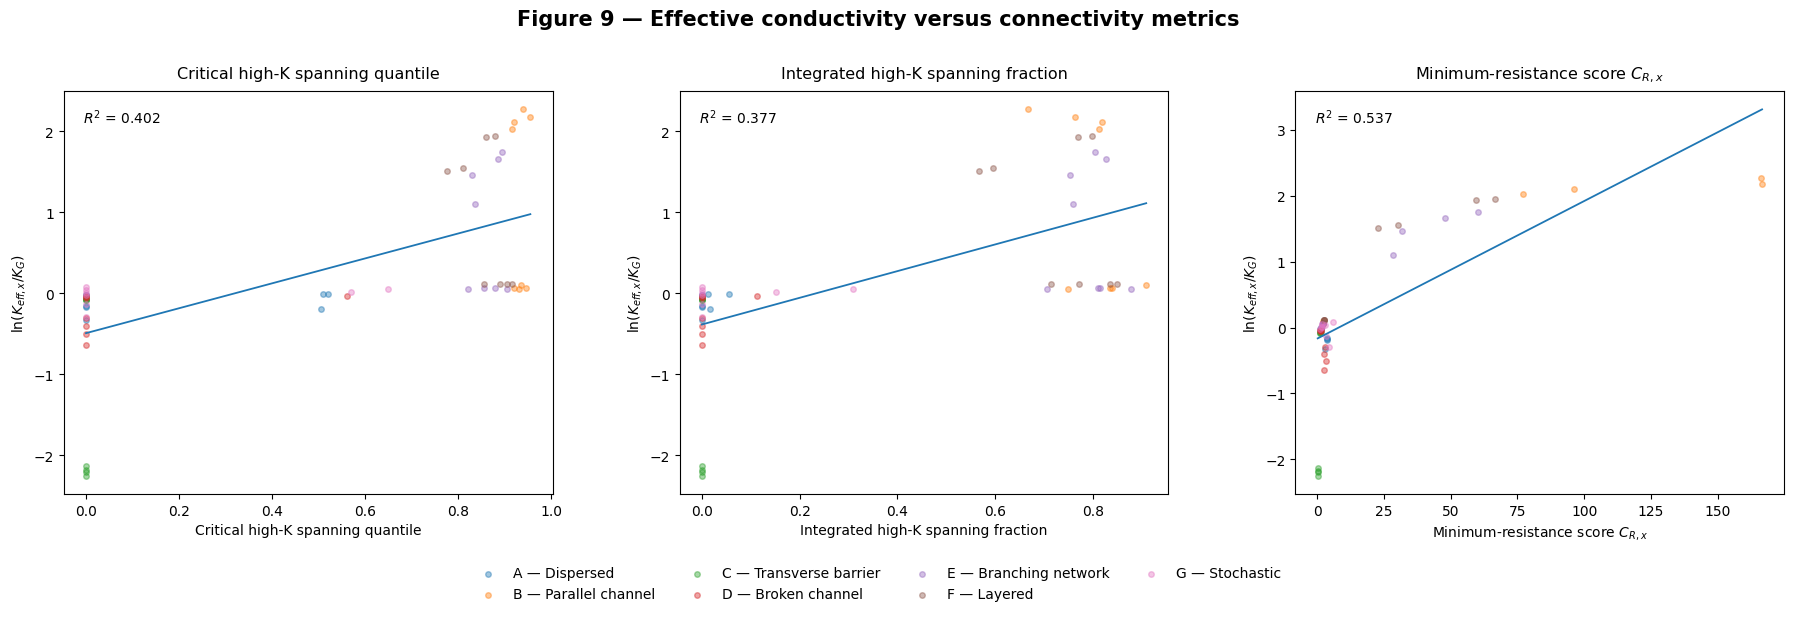

,metric,r,R2,p
2,C_R_x,0.733097,0.537431,1.323979e-10
0,qcrit_high_x,0.634192,0.402199,1.540536e-07
1,Cspan_high_x,0.613814,0.376768,4.888942e-07


In [17]:
# Defensive label definitions in case this cell is run independently
if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        'A':'Dispersed',
        'B':'Parallel channel',
        'C':'Transverse barrier',
        'D':'Broken channel',
        'E':'Branching network',
        'F':'Layered',
        'G':'Stochastic'
    }


metrics=[
    ('qcrit_high_x','Critical high-K spanning quantile'),
    ('Cspan_high_x','Integrated high-K spanning fraction'),
    ('C_R_x','Minimum-resistance score $C_{R,x}$')
]

fig,axes=plt.subplots(1,3,figsize=(18.5,6.3))
cor=[]

for ax,(col,xlab) in zip(axes,metrics):
    d=results[[col,'ln_Kx_over_KG','case']].replace(
        [np.inf,-np.inf],np.nan
    ).dropna()

    for c in CASE_ORDER:
        s=d[d.case==c]
        ax.scatter(
            s[col],s.ln_Kx_over_KG,
            s=16,alpha=.42,
            label=f'{c} — {CASE_SHORT[c]}'
        )

    if len(d)>3 and d[col].std()>0:
        lr=linregress(d[col],d.ln_Kx_over_KG)
        xx=np.linspace(d[col].min(),d[col].max(),100)
        ax.plot(xx,lr.intercept+lr.slope*xx,linewidth=1.3)
        cor.append({
            'metric':col,
            'r':lr.rvalue,
            'R2':lr.rvalue**2,
            'p':lr.pvalue
        })
        ax.text(
            .04,.96,
            f'$R^2$ = {lr.rvalue**2:.3f}',
            transform=ax.transAxes,
            va='top'
        )

    ax.set_xlabel(xlab)
    ax.set_ylabel('$\\ln(K_{eff,x}/K_G)$')
    ax.set_title(xlab,fontsize=11.5,pad=9)

handles,labels_=axes[0].get_legend_handles_labels()
fig.legend(
    handles,labels_,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.01)
)
fig.suptitle(
    'Figure 9 — Effective conductivity versus connectivity metrics',
    fontsize=15,fontweight='semibold',y=0.97
)
fig.subplots_adjust(left=0.06,right=0.99,bottom=0.20,top=0.84,wspace=0.26)
plt.show()
savefig(fig,'Fig09_connectivity_vs_Keff.png')

corr_table=pd.DataFrame(cor).sort_values('R2',ascending=False)
display(corr_table)


# 22. Figures 10–11 — classical means and topology ranking

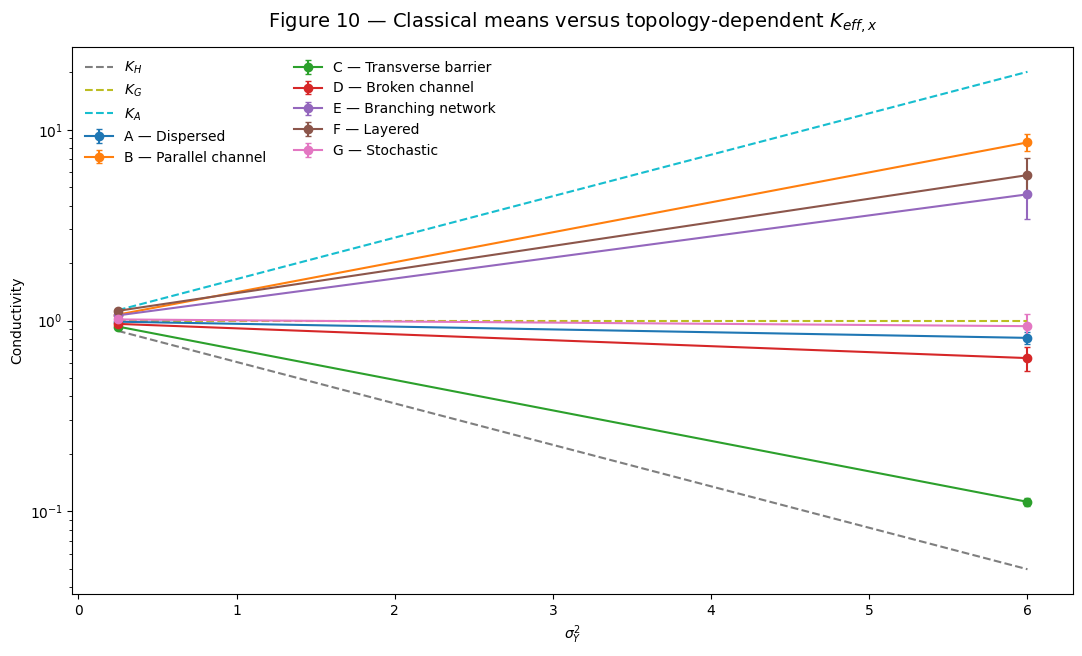

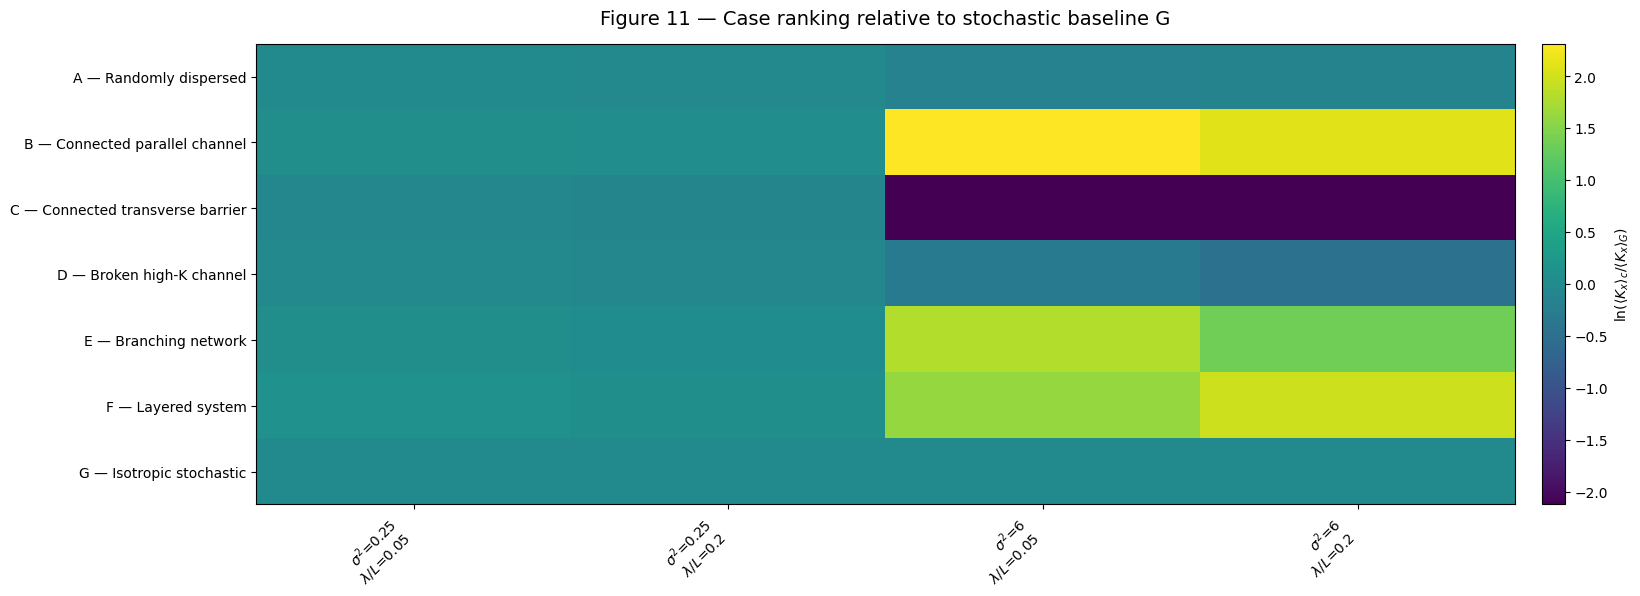

PosixPath('/content/connectivity_seven_case_study/figures/Fig11_case_ranking.png')

In [18]:
# Defensive label definitions in case this cell is run independently
if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        'A':'Dispersed',
        'B':'Parallel channel',
        'C':'Transverse barrier',
        'D':'Broken channel',
        'E':'Branching network',
        'F':'Layered',
        'G':'Stochastic'
    }


# ---------------- Figure 10 ----------------
fig,ax=plt.subplots(figsize=(11.5,7.2))

for c in CASE_ORDER:
    d=(
        results[results.case==c]
        .groupby('sigma2')
        .Keff_x.agg(['mean','std'])
        .reset_index()
    )
    ax.errorbar(
        d.sigma2,d['mean'],yerr=d['std'],
        marker='o',capsize=2,
        label=f'{c} — {CASE_SHORT[c]}'
    )

s=np.linspace(min(SIGMA2_VALUES),max(SIGMA2_VALUES),300)
ax.plot(s,np.exp(-s/2),linestyle='--',label='$K_H$')
ax.plot(s,np.ones_like(s),linestyle='--',label='$K_G$')
ax.plot(s,np.exp(s/2),linestyle='--',label='$K_A$')

ax.set_yscale('log')
ax.set_xlabel('$\\sigma_Y^2$')
ax.set_ylabel('Conductivity')
ax.set_title(
    'Figure 10 — Classical means versus topology-dependent $K_{eff,x}$',
    fontsize=14,pad=14
)
ax.legend(ncol=2,frameon=False)
fig.subplots_adjust(left=0.10,right=0.97,bottom=0.11,top=0.87)
plt.show()
savefig(fig,'Fig10_classical_means.png')

# ---------------- Figure 11 ----------------
cm=(
    results.groupby(['sigma2','lambda_parent_rel','case'])
    .Keff_x.mean().reset_index()
)
bg=(
    cm[cm.case=='G'][['sigma2','lambda_parent_rel','Keff_x']]
    .rename(columns={'Keff_x':'KGbase'})
)
rankdf=cm.merge(bg,on=['sigma2','lambda_parent_rel'])
rankdf['ln_ratio_vs_G']=np.log(rankdf.Keff_x/rankdf.KGbase)

conds=sorted(
    rankdf[['sigma2','lambda_parent_rel']]
    .drop_duplicates()
    .itertuples(index=False,name=None)
)
mat=np.full((7,len(conds)),np.nan)

for j,(s2,lam) in enumerate(conds):
    d=rankdf[
        np.isclose(rankdf.sigma2,s2)
        & np.isclose(rankdf.lambda_parent_rel,lam)
    ]
    for i,c in enumerate(CASE_ORDER):
        z=d[d.case==c].ln_ratio_vs_G
        if len(z):
            mat[i,j]=z.iloc[0]

fig,ax=plt.subplots(figsize=(18.5,7.2))
im=ax.imshow(mat,aspect='auto')

ax.set_yticks(
    range(7),
    [f'{c} — {CASE_NAMES[c]}' for c in CASE_ORDER]
)
ax.set_xticks(
    range(len(conds)),
    [
        f'$\\sigma^2$={s:g}\n$\\lambda/L$={l:g}'
        for s,l in conds
    ],
    rotation=45,
    ha='right'
)
fig.colorbar(
    im,ax=ax,
    label='$\\ln(\\langle K_x\\rangle_c/\\langle K_x\\rangle_G)$',
    fraction=0.035,pad=0.02
)
ax.set_title(
    'Figure 11 — Case ranking relative to stochastic baseline G',
    fontsize=14,pad=14
)
fig.subplots_adjust(left=0.22,right=0.94,bottom=0.24,top=0.88)
plt.show()
savefig(fig,'Fig11_case_ranking.png')


# 23. Figures 12–13 — topology-dominance regime map and uncertainty reduction

/tmp/ipykernel_2090/2353943105.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(effect_stats)


,sigma2,lambda_parent_rel,eta2_topology,Delta_log_max_min,case_max,case_min
0,0.25,0.05,0.989458,0.186973,F,C
1,0.25,0.20,0.971588,0.192375,F,C
2,6.00,0.05,0.996000,4.435343,B,C
3,6.00,0.20,0.995920,4.230389,B,C


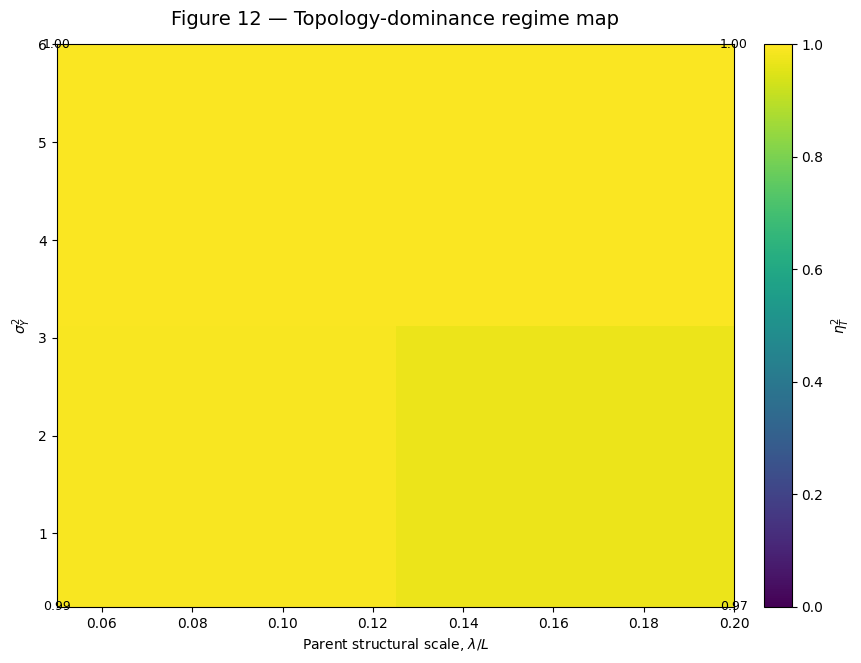

/tmp/ipykernel_2090/2353943105.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ureduction)


,sigma2,lambda_parent_rel,U,Ures,reduction,adj_R2
0,0.25,0.05,0.004120,0.000102,0.975134,0.935349
1,0.25,0.20,0.004582,0.000076,0.983370,0.956763
2,6.00,0.05,2.227593,0.188112,0.915554,0.780439
3,6.00,0.20,2.139547,0.271865,0.872933,0.669626


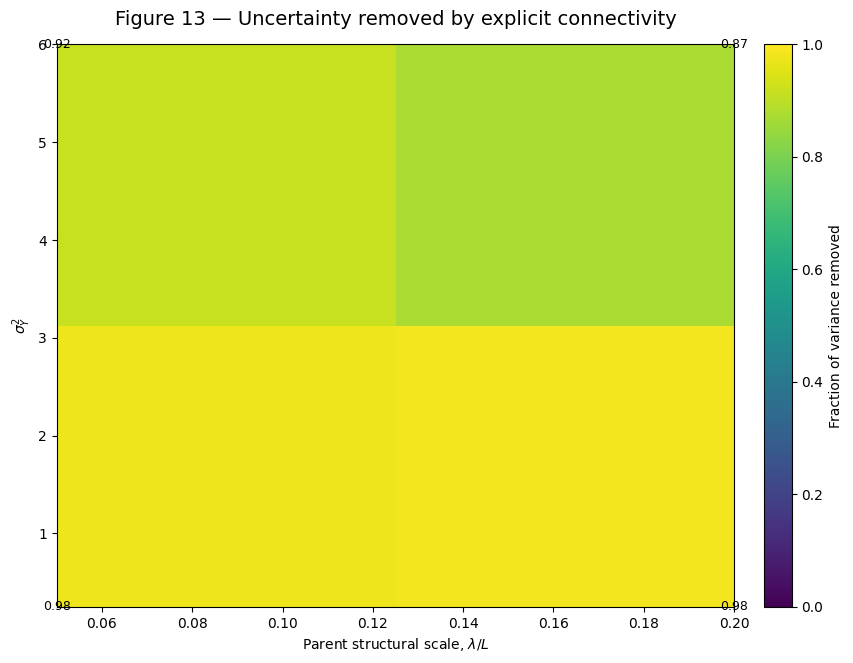

,model,adj_R2,AIC,BIC,resid_var
0,conventional statistics,-0.010967,165.802206,171.878262,1.034328
1,+ connectivity descriptors,0.692591,105.971860,128.250728,0.267039


In [19]:

def effect_stats(g):
    y=np.log(g.Keff_x.values)
    grand=y.mean()
    sst=np.sum((y-grand)**2)
    ssc=0
    means={}

    for c,sub in g.groupby('case'):
        yy=np.log(sub.Keff_x.values)
        means[c]=sub.Keff_x.mean()
        ssc+=len(yy)*(yy.mean()-grand)**2

    vals=np.array(list(means.values()))
    return pd.Series({
        'eta2_topology':ssc/sst if sst>0 else np.nan,
        'Delta_log_max_min':np.log(vals.max()/vals.min()),
        'case_max':max(means,key=means.get),
        'case_min':min(means,key=means.get)
    })

regime=(
    results.groupby(['sigma2','lambda_parent_rel'])
    .apply(effect_stats)
    .reset_index()
)
display(regime)

# ---------------- Figure 12 ----------------
piv=regime.pivot(
    index='sigma2',
    columns='lambda_parent_rel',
    values='eta2_topology'
).reindex(
    index=SIGMA2_VALUES,
    columns=LAMBDA_REL_VALUES
)

fig,ax=plt.subplots(figsize=(9.5,7.4))
im=ax.imshow(
    piv.values,
    origin='lower',
    aspect='auto',
    extent=[
        min(LAMBDA_REL_VALUES),max(LAMBDA_REL_VALUES),
        min(SIGMA2_VALUES),max(SIGMA2_VALUES)
    ],
    vmin=0,vmax=1
)
fig.colorbar(im,ax=ax,label='$\\eta_T^2$',fraction=0.046,pad=0.04)
ax.set_xlabel('Parent structural scale, $\\lambda/L$')
ax.set_ylabel('$\\sigma_Y^2$')
ax.set_title(
    'Figure 12 — Topology-dominance regime map',
    fontsize=14,pad=14
)

for _,r in regime.iterrows():
    ax.text(
        r.lambda_parent_rel,r.sigma2,
        f'{r.eta2_topology:.2f}',
        ha='center',va='center',fontsize=9
    )

fig.subplots_adjust(left=0.12,right=0.90,bottom=0.12,top=0.88)
plt.show()
savefig(fig,'Fig12_topology_dominance.png')

PRED=[
    'qcrit_high_x','Cspan_high_x','C_R_x',
    'qcrit_low_x','Cspan_low_x',
    'qcrit_high_y','Cspan_high_y','C_R_y'
]

def ureduction(g):
    d=g[['Keff_x']+PRED].replace(
        [np.inf,-np.inf],np.nan
    ).dropna()

    if len(d)<12:
        return pd.Series({
            'U':np.nan,'Ures':np.nan,
            'reduction':np.nan,'adj_R2':np.nan
        })

    y=np.log(d.Keff_x.values)
    U=np.var(y,ddof=1)
    fit=sm.OLS(
        y,sm.add_constant(d[PRED])
    ).fit()
    Ur=np.var(fit.resid,ddof=1)

    return pd.Series({
        'U':U,
        'Ures':Ur,
        'reduction':1-Ur/U if U>0 else np.nan,
        'adj_R2':fit.rsquared_adj
    })

uncertainty=(
    results.groupby(['sigma2','lambda_parent_rel'])
    .apply(ureduction)
    .reset_index()
)
display(uncertainty)

# ---------------- Figure 13 ----------------
up=uncertainty.pivot(
    index='sigma2',
    columns='lambda_parent_rel',
    values='reduction'
).reindex(
    index=SIGMA2_VALUES,
    columns=LAMBDA_REL_VALUES
)

fig,ax=plt.subplots(figsize=(9.5,7.4))
im=ax.imshow(
    up.values,
    origin='lower',
    aspect='auto',
    extent=[
        min(LAMBDA_REL_VALUES),max(LAMBDA_REL_VALUES),
        min(SIGMA2_VALUES),max(SIGMA2_VALUES)
    ],
    vmin=0,vmax=1
)
fig.colorbar(
    im,ax=ax,
    label='Fraction of variance removed',
    fraction=0.046,pad=0.04
)
ax.set_xlabel('Parent structural scale, $\\lambda/L$')
ax.set_ylabel('$\\sigma_Y^2$')
ax.set_title(
    'Figure 13 — Uncertainty removed by explicit connectivity',
    fontsize=14,pad=14
)

for _,r in uncertainty.iterrows():
    if np.isfinite(r.reduction):
        ax.text(
            r.lambda_parent_rel,r.sigma2,
            f'{r.reduction:.2f}',
            ha='center',va='center',fontsize=9
        )

fig.subplots_adjust(left=0.12,right=0.90,bottom=0.12,top=0.88)
plt.show()
savefig(fig,'Fig13_uncertainty_reduction.png')

rd=results.replace(
    [np.inf,-np.inf],np.nan
).dropna(
    subset=['ln_Kx_over_KG','sigma2','lambda_parent_rel']+PRED
)

if len(rd) >= len(PRED)+5:
    fit0=sm.OLS(
        rd.ln_Kx_over_KG,
        sm.add_constant(rd[['sigma2','lambda_parent_rel']])
    ).fit()
    fit1=sm.OLS(
        rd.ln_Kx_over_KG,
        sm.add_constant(
            rd[['sigma2','lambda_parent_rel']+PRED]
        )
    ).fit()

    closure_comparison=pd.DataFrame([
        {
            'model':'conventional statistics',
            'adj_R2':fit0.rsquared_adj,
            'AIC':fit0.aic,
            'BIC':fit0.bic,
            'resid_var':np.var(fit0.resid,ddof=1)
        },
        {
            'model':'+ connectivity descriptors',
            'adj_R2':fit1.rsquared_adj,
            'AIC':fit1.aic,
            'BIC':fit1.bic,
            'resid_var':np.var(fit1.resid,ddof=1)
        }
    ])
else:
    closure_comparison=pd.DataFrame([
        {
            'model':'conventional statistics',
            'adj_R2':np.nan,'AIC':np.nan,
            'BIC':np.nan,'resid_var':np.nan
        },
        {
            'model':'+ connectivity descriptors',
            'adj_R2':np.nan,'AIC':np.nan,
            'BIC':np.nan,'resid_var':np.nan
        }
    ])
    print('Not enough complete rows for the global OLS closure in this run mode.')

display(closure_comparison)


# 24. Independent P1 finite-element verification

In [20]:
def fem_p1_solve_x(Kcell,Lx=1.0,Ly=1.0,h_left=1.0,h_right=0.0):
    Kcell=np.asarray(Kcell,float); ny,nx=Kcell.shape; xs=np.linspace(0,Lx,nx+1); ys=np.linspace(0,Ly,ny+1); Xn,Yn=np.meshgrid(xs,ys); coords=np.c_[Xn.ravel(),Yn.ravel()]; nn=len(coords)
    def nid(j,i):return j*(nx+1)+i
    A=lil_matrix((nn,nn)); elems=[]
    for j in range(ny):
        for i in range(nx):
            tris=[(nid(j,i),nid(j,i+1),nid(j+1,i+1)),(nid(j,i),nid(j+1,i+1),nid(j+1,i))]; kval=Kcell[j,i]
            for tri in tris:
                p=coords[list(tri)]; x1,y1=p[0];x2,y2=p[1];x3,y3=p[2]; area=.5*abs((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1)); bv=np.array([y2-y3,y3-y1,y1-y2]); cv=np.array([x3-x2,x1-x3,x2-x1]); B=np.vstack([bv,cv])/(2*area); Ke=kval*area*(B.T@B)
                for a in range(3):
                    for b in range(3):A[tri[a],tri[b]]+=Ke[a,b]
                elems.append((tri,Ke))
    A=A.tocsr(); rhs=np.zeros(nn); left=np.array([nid(j,0) for j in range(ny+1)]); right=np.array([nid(j,nx) for j in range(ny+1)]); fixed=np.unique(np.r_[left,right]); hfix=np.zeros(nn); hfix[left]=h_left; hfix[right]=h_right; free=np.setdiff1d(np.arange(nn),fixed)
    h=np.zeros(nn); h[fixed]=hfix[fixed]; h[free]=spsolve(A[free][:,free],rhs[free]-A[free][:,fixed]@hfix[fixed]); energy=0.0
    for tri,Ke in elems:
        he=h[list(tri)]; energy+=float(he@Ke@he)
    return h.reshape(ny+1,nx+1),float(energy*Lx/(Ly*(h_left-h_right)**2))

FEM_N=20 if RUN_MODE=='DEMO' else 44; vr=[]
FEM_SIGMA_VALUES=[max(SIGMA2_VALUES)] if RUN_MODE=='DEMO' else [2.0,max(SIGMA2_VALUES)]
for s2 in FEM_SIGMA_VALUES:
    Yv,Kv,_=make_suite(FEM_N,FEM_N,Lx,Ly,.10,s2,MASTER_SEED+int(100*s2)+555,PAD_FACTOR)
    for c in CASE_ORDER:
        f=solve_fvm_x(Kv[c],Lx,Ly,H_LEFT,H_RIGHT,THICKNESS,SOLVER); _,kf=fem_p1_solve_x(Kv[c],Lx,Ly,H_LEFT,H_RIGHT)
        vr.append({'sigma2':s2,'case':c,'Keff_FVM':f.Keff,'Keff_FEM':kf,'rel_diff':abs(f.Keff-kf)/max(abs(kf),1e-30)})
verification=pd.DataFrame(vr); display(verification)

,sigma2,case,Keff_FVM,Keff_FEM,rel_diff
0,6.0,A,0.658328,1.044147,0.369507
1,6.0,B,7.285923,8.713756,0.163860
2,6.0,C,0.209740,0.217920,0.037534
3,6.0,D,0.724077,0.785462,0.078152
4,6.0,E,2.606122,2.896857,0.100362
5,6.0,F,3.902377,3.970528,0.017164
6,6.0,G,0.701658,0.838283,0.162982


# 25. Grid convergence, Figure 14, and complete export

,case,N,Keff_x,mass_error,rel_change_next
0,A,24,0.861873,2.189857e-15,0.023679
1,A,48,0.882776,1.026242e-13,0.036163
2,A,96,0.915898,2.984359e-13,NaN
3,B,24,2.993641,1.780130e-15,0.152833
4,B,48,3.533707,3.732468e-14,0.051595
5,B,96,3.725947,9.475467e-14,NaN
6,C,24,0.226784,1.068447e-13,0.099825
7,C,48,0.206200,1.120454e-12,0.022094
8,C,96,0.201742,1.249770e-12,NaN
9,D,24,0.755853,1.711192e-13,0.015564


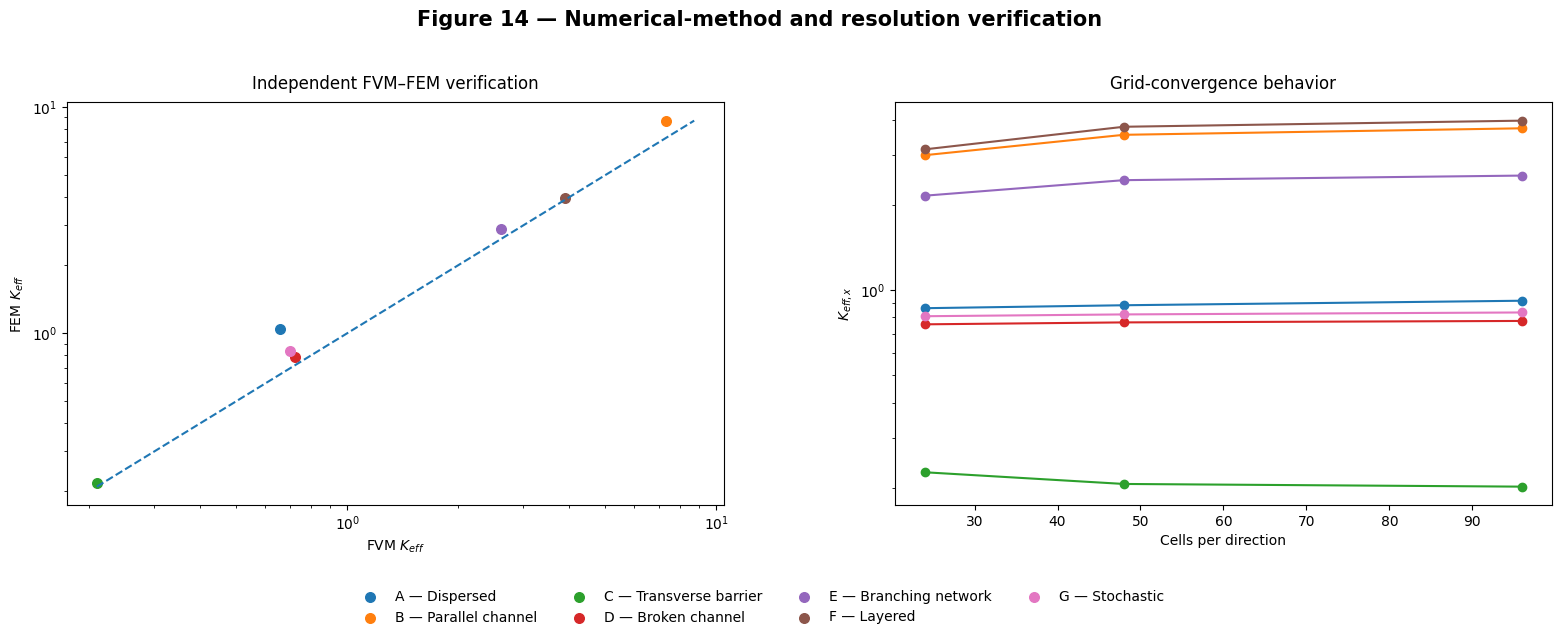

Study folder: /content/connectivity_seven_case_study
ZIP: /content/Groundwater_Connectivity_Seven_Cases_DEMO.zip


In [21]:
# Defensive label definitions in case this cell is run independently
if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        'A':'Dispersed',
        'B':'Parallel channel',
        'C':'Transverse barrier',
        'D':'Broken channel',
        'E':'Branching network',
        'F':'Layered',
        'G':'Stochastic'
    }


def block_average(a,f):
    ny,nx=a.shape
    return a.reshape(
        ny//f,f,nx//f,f
    ).mean(axis=(1,3))

NHI=96 if RUN_MODE=='DEMO' else 256
Yhi,Khi,_=make_suite(
    NHI,NHI,Lx,Ly,.10,4.0,
    MASTER_SEED+909,PAD_FACTOR
)

gr=[]
for c in CASE_ORDER:
    for fac in [4,2,1]:
        Yg=block_average(Yhi[c],fac) if fac>1 else Yhi[c].copy()
        Kg=np.exp(Yg)
        f=solve_fvm_x(
            Kg,Lx,Ly,H_LEFT,H_RIGHT,THICKNESS,SOLVER
        )
        gr.append({
            'case':c,
            'N':Kg.shape[1],
            'Keff_x':f.Keff,
            'mass_error':f.mass_error
        })

gridconv=pd.DataFrame(gr).sort_values(['case','N'])
gridconv['rel_change_next']=np.nan

for c in CASE_ORDER:
    ids=sorted(
        gridconv.index[gridconv.case==c],
        key=lambda i:gridconv.loc[i,'N']
    )
    for a,b in zip(ids[:-1],ids[1:]):
        gridconv.loc[a,'rel_change_next']=(
            abs(
                gridconv.loc[a,'Keff_x']
                - gridconv.loc[b,'Keff_x']
            )
            / abs(gridconv.loc[b,'Keff_x'])
        )

display(gridconv)

# ---------------- Figure 14 ----------------
fig,axes=plt.subplots(1,2,figsize=(16.5,6.6))

for c in CASE_ORDER:
    d=verification[verification.case==c]
    axes[0].scatter(
        d.Keff_FVM,d.Keff_FEM,
        s=48,label=f'{c} — {CASE_SHORT[c]}'
    )

mn=min(verification[['Keff_FVM','Keff_FEM']].min())
mx=max(verification[['Keff_FVM','Keff_FEM']].max())
axes[0].plot([mn,mx],[mn,mx],linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('FVM $K_{eff}$')
axes[0].set_ylabel('FEM $K_{eff}$')
axes[0].set_title('Independent FVM–FEM verification',fontsize=12,pad=10)

for c in CASE_ORDER:
    d=gridconv[gridconv.case==c].sort_values('N')
    axes[1].plot(
        d.N,d.Keff_x,
        marker='o',
        label=f'{c} — {CASE_SHORT[c]}'
    )

axes[1].set_yscale('log')
axes[1].set_xlabel('Cells per direction')
axes[1].set_ylabel('$K_{eff,x}$')
axes[1].set_title('Grid-convergence behavior',fontsize=12,pad=10)

handles,labels_=axes[0].get_legend_handles_labels()
fig.legend(
    handles,labels_,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.01)
)
fig.suptitle(
    'Figure 14 — Numerical-method and resolution verification',
    fontsize=15,fontweight='semibold',y=0.96
)
fig.subplots_adjust(left=0.08,right=0.98,bottom=0.21,top=0.82,wspace=0.26)
plt.show()
savefig(fig,'Fig14_verification.png')

# ---------------- Export tables ----------------
results.to_csv(
    DATA_DIR/f'all_A_to_G_{RUN_MODE.lower()}.csv',
    index=False
)
summary.to_csv(
    DATA_DIR/'directional_summary.csv',
    index=False
)
diag.to_csv(
    DATA_DIR/'example_diagnostics.csv',
    index=False
)
corr_table.to_csv(
    DATA_DIR/'connectivity_correlations.csv',
    index=False
)
regime.to_csv(
    DATA_DIR/'topology_regime.csv',
    index=False
)
uncertainty.to_csv(
    DATA_DIR/'uncertainty_reduction.csv',
    index=False
)
closure_comparison.to_csv(
    DATA_DIR/'closure_comparison.csv',
    index=False
)
verification.to_csv(
    DATA_DIR/'FVM_FEM_verification.csv',
    index=False
)
gridconv.to_csv(
    DATA_DIR/'grid_convergence.csv',
    index=False
)
qc.to_csv(
    DATA_DIR/'quality_control.csv',
    index=False
)
rankdf.to_csv(
    DATA_DIR/'case_ranking_vs_G.csv',
    index=False
)

paired=results.pivot_table(
    index=['sigma2','lambda_parent_rel','realization'],
    columns='case',
    values='Keff_x'
).reset_index()

for c in CASE_ORDER:
    if c!='G' and c in paired:
        paired[f'ln_{c}_over_G']=np.log(paired[c]/paired['G'])

if 'D' in paired and 'B' in paired:
    paired['ln_D_over_B']=np.log(paired['D']/paired['B'])

paired.to_csv(
    DATA_DIR/'paired_A_to_G_Keff.csv',
    index=False
)

metadata={
    'RUN_MODE':RUN_MODE,
    'NX':NX,
    'NY':NY,
    'SIGMA2_VALUES':SIGMA2_VALUES,
    'LAMBDA_REL_VALUES':LAMBDA_REL_VALUES,
    'N_REALIZATIONS':N_REALIZATIONS,
    'MASTER_SEED':MASTER_SEED,
    'cases':CASE_NAMES
}
(ROOT/'run_metadata.json').write_text(
    json.dumps(metadata,indent=2)
)

case_global=results.groupby('case').agg(
    Kx=('Keff_x','mean'),
    Ky=('Keff_y','mean'),
    anis=('Kx_over_Ky','mean'),
    F10=('F10_flux','mean'),
    G10=('G10_gradient','mean')
).reset_index()

(ROOT/'automatic_summary.txt').write_text(
    'SEVEN-CASE CONNECTIVITY STUDY\n'
    +case_global.to_string(index=False)
    +'\n\n'
    +regime.to_string(index=False)
    +'\n\n'
    +closure_comparison.to_string(index=False)
)

zip_path=Path('/content')/f'Groundwater_Connectivity_Seven_Cases_{RUN_MODE}.zip'

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    str(zip_path.with_suffix('')),
    'zip',
    root_dir=str(ROOT)
)

print('Study folder:',ROOT)
print('ZIP:',zip_path)

# Google Colab download:
# from google.colab import files
# files.download(str(zip_path))


## Interpretation discipline

The common histogram makes the A–G comparison much stronger than independently generated conductivity fields: differences in flow cannot be attributed to different conductivity populations.

However, the seven structures are intentionally geometrically different, so their directional covariance/variogram structures may differ. Figures 2–3 and the exported diagnostics must therefore remain part of the scientific interpretation. If the first paper later requires a stricter **iso-variogram** experiment, that should be added as a separate controlled experiment rather than silently assuming it here.


# Additional publication cell — original MG/HC/LC heat-map style applied to A–G

This final optional cell reproduces the exact plotting philosophy of the earlier three-case workflow:

- `viridis` hydraulic-head heat maps,
- a common head scale across all cases,
- equipotential contours and numerical contour labels,
- `magma` \(\log_{10}|q|\) maps,
- one common flux color scale calculated from all seven cases,
- Darcy-flux vectors,
- and the clean **3–3–1** A–G layout.

It uses the seven-case solver `solve_fvm_x()` already defined in this notebook.


Case A | Randomly dispersed             | Keff = 0.863236 | mass error = 2.694e-13
Case B | Connected parallel channel     | Keff = 4.50339 | mass error = 4.282e-13
Case C | Connected transverse barrier   | Keff = 0.23406 | mass error = 4.271e-13
Case D | Broken high-K channel          | Keff = 0.591889 | mass error = 1.744e-12
Case E | Branching network              | Keff = 3.94285 | mass error = 6.330e-14
Case F | Layered system                 | Keff = 3.9358 | mass error = 1.302e-13
Case G | Isotropic stochastic           | Keff = 0.760285 | mass error = 1.837e-12


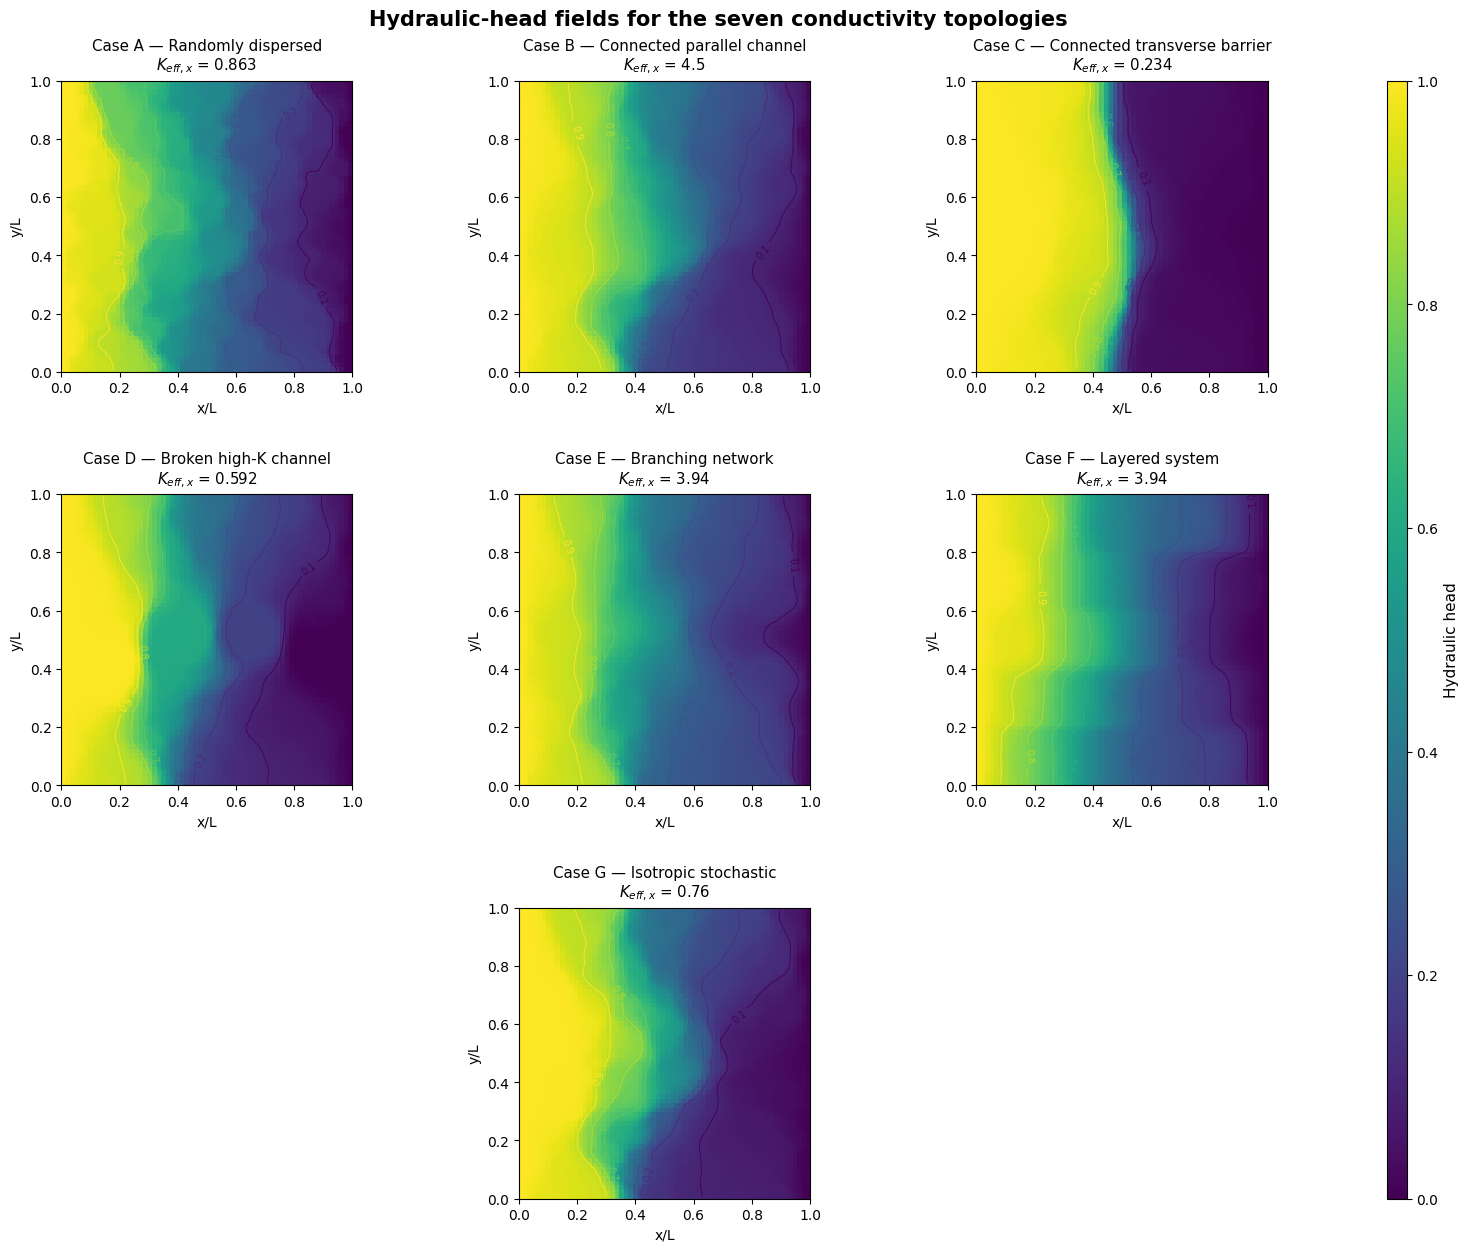


Common Darcy-flux color limits:
qvmin = -1.530161
qvmax = 1.576473


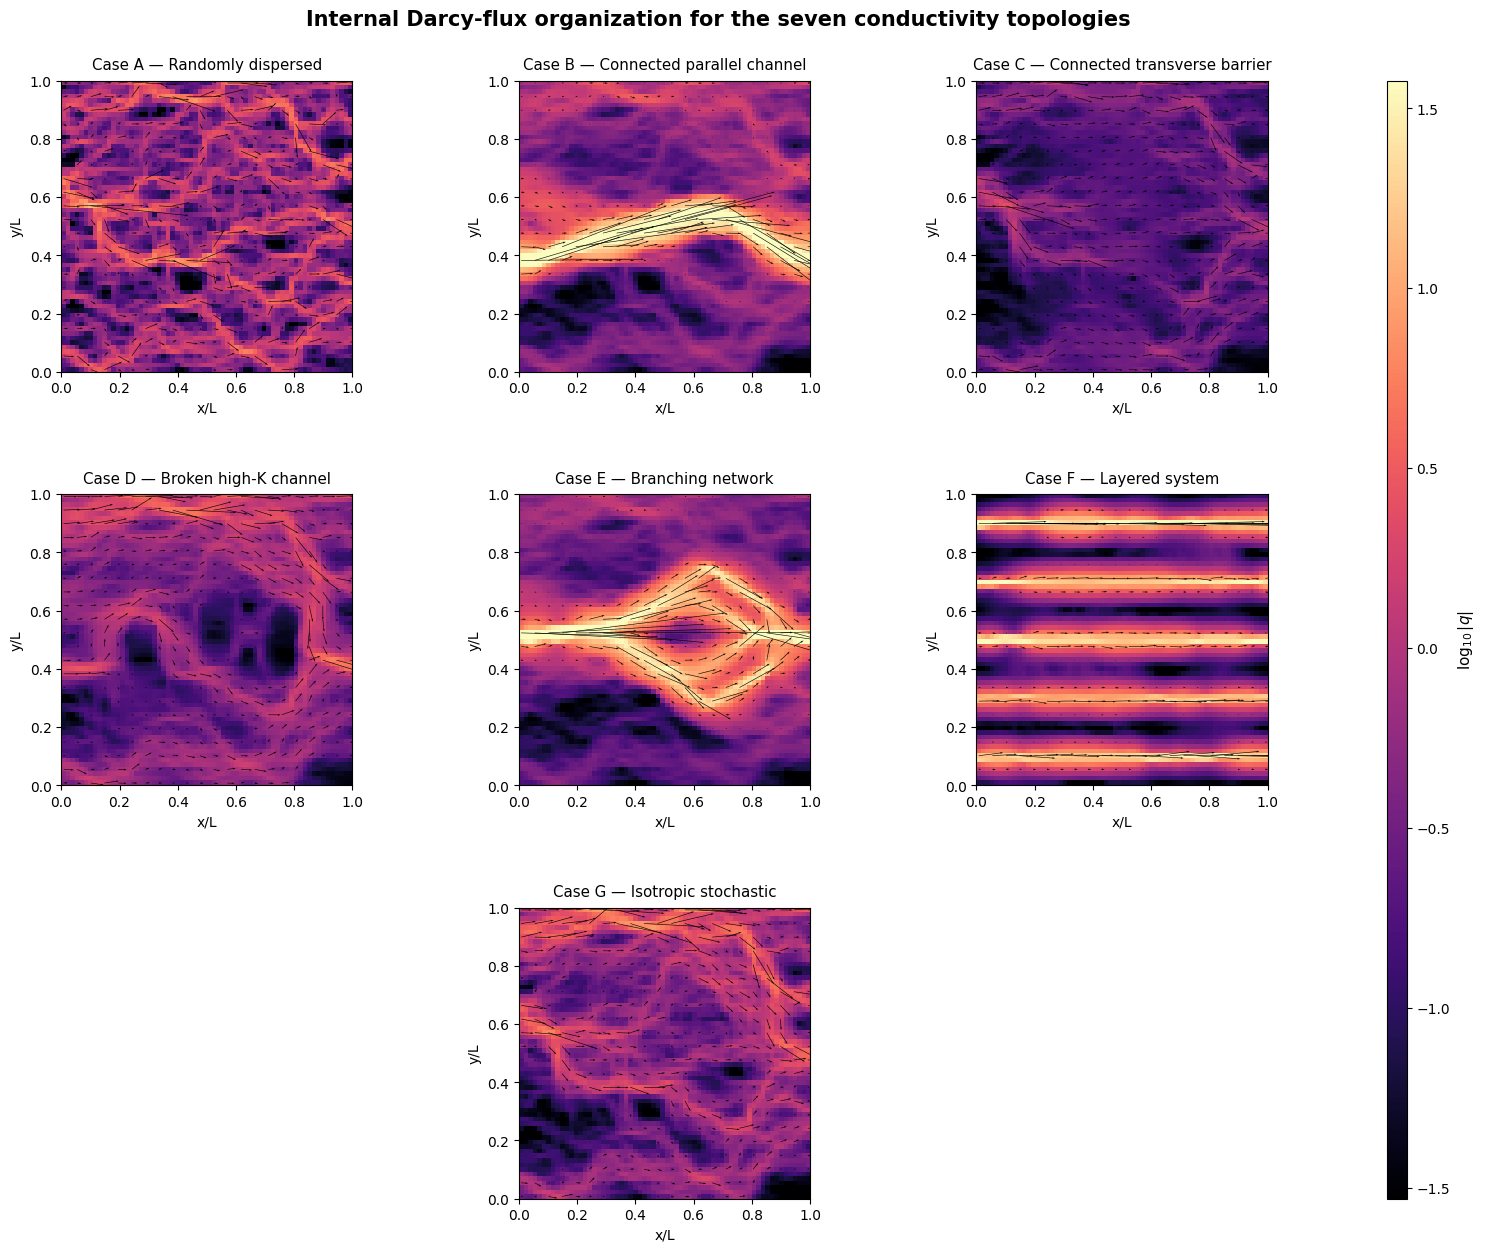

PosixPath('/content/connectivity_seven_case_study/figures/Fig16_Seven_Cases_Darcy_Flux_Original_Style.png')

In [22]:

# ================================================================
# ADDITIONAL FIGURES — SAME STYLE AS ORIGINAL MG / HC / LC METHOD
# APPLIED TO ALL SEVEN CASES A–G
# ================================================================

# ----------------------------------------------------------------
# Defensive definitions: this prevents CASE_SHORT NameError even if
# this plotting cell is run directly after the model-definition cells.
# ----------------------------------------------------------------
if 'CASE_ORDER' not in globals():
    CASE_ORDER = list("ABCDEFG")

if 'CASE_NAMES' not in globals():
    CASE_NAMES = {
        "A": "Randomly dispersed",
        "B": "Connected parallel channel",
        "C": "Connected transverse barrier",
        "D": "Broken high-K channel",
        "E": "Branching network",
        "F": "Layered system",
        "G": "Isotropic stochastic"
    }

if 'CASE_SHORT' not in globals():
    CASE_SHORT = {
        "A": "Dispersed",
        "B": "Parallel channel",
        "C": "Transverse barrier",
        "D": "Broken channel",
        "E": "Branching network",
        "F": "Layered",
        "G": "Stochastic"
    }

# ================================================================
# 1. SOLVE ALL SEVEN CASES
# ================================================================
example_flow_same_style = {}

for case in CASE_ORDER:

    # The seven-case notebook uses solve_fvm_x()
    flow = solve_fvm_x(
        example_K[case],
        Lx,
        Ly,
        H_LEFT,
        H_RIGHT,
        THICKNESS,
        solver=SOLVER
    )

    example_flow_same_style[case] = flow

    print(
        f"Case {case} | "
        f"{CASE_NAMES[case]:30s} | "
        f"Keff = {flow.Keff:.6g} | "
        f"mass error = {flow.mass_error:.3e}"
    )


# ================================================================
# 2. CELL-CENTER COORDINATES
# ================================================================
x_centers = (np.arange(NX) + 0.5) * Lx / NX
y_centers = (np.arange(NY) + 0.5) * Ly / NY
Xc, Yc = np.meshgrid(x_centers, y_centers)


# ================================================================
# 3. CLEAN 4–3 PANEL LAYOUT
#
# Row 1: A  B  C  D
# Row 2:    E  F  G
# ================================================================

def make_original_style_331_figure(
    title,
    figsize=(19.0, 9.8),
    colorbar=True
):

    """
    Organized 4-3 publication layout.

    Row 1: A  B  C  D
    Row 2:    E  F  G

    The second row is centered below the first row.
    """

    fig = plt.figure(figsize=figsize)

    if colorbar:

        gs = fig.add_gridspec(
            2,
            9,
            width_ratios=[1,1,1,1,1,1,1,1,0.10],
            height_ratios=[1,1],
            left=0.05,
            right=0.94,
            bottom=0.08,
            top=0.86 if str(title).strip() else 0.96,
            wspace=0.36,
            hspace=0.42
        )

        cax = fig.add_subplot(gs[:, 8])

    else:

        gs = fig.add_gridspec(
            2,
            8,
            width_ratios=[1,1,1,1,1,1,1,1],
            height_ratios=[1,1],
            left=0.05,
            right=0.97,
            bottom=0.08,
            top=0.86 if str(title).strip() else 0.96,
            wspace=0.36,
            hspace=0.42
        )

        cax = None

    positions = {
        "A": (0, slice(0,2)),
        "B": (0, slice(2,4)),
        "C": (0, slice(4,6)),
        "D": (0, slice(6,8)),
        "E": (1, slice(1,3)),
        "F": (1, slice(3,5)),
        "G": (1, slice(5,7)),
    }

    axes = {}

    for case in CASE_ORDER:
        row, col = positions[case]
        axes[case] = fig.add_subplot(gs[row, col])

    if str(title).strip():
        fig.suptitle(
            title,
            fontsize=15,
            fontweight="semibold",
            y=0.985
        )

    return fig, axes, cax


# ================================================================
# 4. HYDRAULIC-HEAD FIELDS
#
# Exactly the original method:
#   cmap  = viridis
#   vmin  = H_RIGHT
#   vmax  = H_LEFT
#   equipotential contours
#   contour labels
# ================================================================
fig, axes, cax = make_original_style_331_figure(
    "Hydraulic-head fields for the seven conductivity topologies",
    figsize=(19.0, 9.8),
    colorbar=True
)

# Use physical head values and 9 internal contour levels.
head_levels = np.linspace(
    H_RIGHT + 0.1 * (H_LEFT - H_RIGHT),
    H_LEFT  - 0.1 * (H_LEFT - H_RIGHT),
    9
)

for case in CASE_ORDER:

    ax = axes[case]
    flow = example_flow_same_style[case]

    # ------------------------------------------------------------
    # Viridis hydraulic-head heat map
    # ------------------------------------------------------------
    im_head = ax.imshow(
        flow.h,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="viridis",
        vmin=H_RIGHT,
        vmax=H_LEFT,
        aspect="equal"
    )

    # ------------------------------------------------------------
    # Equipotential contour lines
    # ------------------------------------------------------------
    cs = ax.contour(
        Xc,
        Yc,
        flow.h,
        levels=head_levels,
        linewidths=0.6
    )

    # ------------------------------------------------------------
    # Numerical head labels on contours
    # ------------------------------------------------------------
    ax.clabel(
        cs,
        fontsize=7,
        fmt="%.1f",
        inline=True
    )

    # Two-line title avoids any overlap.
    ax.set_title(
        f"Case {case}\n"
        f"{CASE_NAMES[case]}\n"
        f"$K_{{eff,x}}$ = {flow.Keff:.3g}",
        fontsize=10.2,
        pad=5,
        linespacing=1.0
    )

    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")


# One common colorbar for all seven head panels.
cbar = fig.colorbar(
    im_head,
    cax=cax
)

cbar.set_label(
    "Hydraulic head",
    fontsize=11
)

plt.show()

savefig(
    fig,
    "Fig15_Seven_Cases_Hydraulic_Head_Original_Style.png"
)


# ================================================================
# 5. DARCY-FLUX MAGNITUDE
#
# Exactly the original method:
#   q -> log10(|q|)
#   cmap = magma
#   common 1st–99th percentile limits across ALL seven cases
#   Darcy-vector quiver arrows
# ================================================================

# ------------------------------------------------------------
# Common flux color range across A–G
# ------------------------------------------------------------
all_logq = np.concatenate([
    np.log10(
        np.maximum(
            example_flow_same_style[case].qmag.ravel(),
            1e-20
        )
    )
    for case in CASE_ORDER
])

qvmin, qvmax = np.quantile(
    all_logq,
    [0.01, 0.99]
)

print("\nCommon Darcy-flux color limits:")
print(f"qvmin = {qvmin:.6f}")
print(f"qvmax = {qvmax:.6f}")


# ------------------------------------------------------------
# Flux plots
# ------------------------------------------------------------
fig, axes, cax = make_original_style_331_figure(
    "Internal Darcy-flux organization for the seven conductivity topologies",
    figsize=(19.0, 9.8),
    colorbar=True
)

step = max(1, NX // 20)

for case in CASE_ORDER:

    ax = axes[case]
    flow = example_flow_same_style[case]

    logq = np.log10(
        np.maximum(
            flow.qmag,
            1e-20
        )
    )

    # ------------------------------------------------------------
    # Magma heat map
    # ------------------------------------------------------------
    im_flux = ax.imshow(
        logq,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="magma",
        vmin=qvmin,
        vmax=qvmax,
        aspect="equal"
    )

    # ------------------------------------------------------------
    # Darcy flux vectors
    # ------------------------------------------------------------
    ax.quiver(
        Xc[::step, ::step],
        Yc[::step, ::step],

        flow.qx_cell[::step, ::step],
        flow.qy_cell[::step, ::step],

        scale=None,
        width=0.002
    )

    ax.set_title(
        f"Case {case}\n"
        f"{CASE_NAMES[case]}",
        fontsize=10.2,
        pad=5,
        linespacing=1.0
    )

    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")


# One common colorbar for all seven flux panels.
cbar = fig.colorbar(
    im_flux,
    cax=cax
)

cbar.set_label(
    r"$\log_{10}|q|$",
    fontsize=11
)

plt.show()

savefig(
    fig,
    "Fig16_Seven_Cases_Darcy_Flux_Original_Style.png"
)


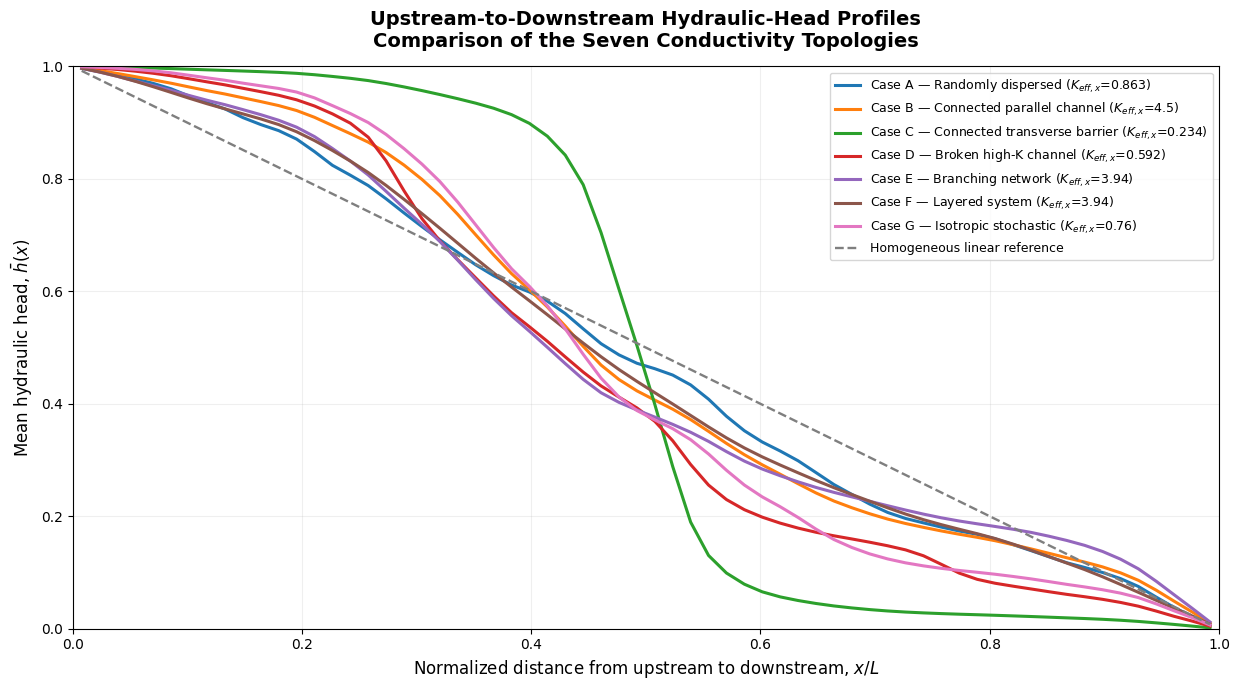

,x/L,Case_A,Case_B,Case_C,Case_D,Case_E,Case_F,Case_G
0,0.007812,0.996871,0.997556,0.999782,0.999112,0.996673,0.996827,0.999477
1,0.023438,0.990678,0.992650,0.999282,0.997073,0.989938,0.990134,0.998259
2,0.039062,0.984659,0.987427,0.998668,0.994577,0.982339,0.982414,0.996721
3,0.054688,0.977780,0.981817,0.997948,0.991566,0.973975,0.973550,0.994746
4,0.070312,0.969825,0.976103,0.997111,0.987828,0.965739,0.963868,0.992076


In [23]:
# ================================================================
# UPSTREAM → DOWNSTREAM HYDRAULIC-HEAD PROFILES
# ALL SEVEN TOPOLOGY CASES IN ONE FIGURE
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Defensive case definitions
# ------------------------------------------------------------
if "CASE_ORDER" not in globals():
    CASE_ORDER = list("ABCDEFG")

if "CASE_NAMES" not in globals():
    CASE_NAMES = {
        "A": "Randomly dispersed",
        "B": "Connected parallel channel",
        "C": "Connected transverse barrier",
        "D": "Broken high-K channel",
        "E": "Branching network",
        "F": "Layered system",
        "G": "Isotropic stochastic"
    }


# ================================================================
# 1. GET FLOW RESULTS
#
# Works with either:
#
# example_flow_same_style[case] = FlowResult
#
# OR
#
# example_flow[case] = (flow_x, flow_y)
# ================================================================

def get_x_flow(case):

    # Last plotting cell
    if "example_flow_same_style" in globals():
        return example_flow_same_style[case]

    # Earlier seven-case notebook
    elif "example_flow" in globals():

        obj = example_flow[case]

        # If stored as (x-flow, y-flow)
        if isinstance(obj, tuple):
            return obj[0]

        # If stored directly as FlowResult
        return obj

    else:
        raise NameError(
            "No flow results found. Run the seven-case FVM solution cell first."
        )


# ================================================================
# 2. X COORDINATES
# ================================================================

x_centers = (
    np.arange(NX) + 0.5
) * Lx / NX

x_norm = x_centers / Lx


# ================================================================
# 3. CREATE FIGURE
# ================================================================

fig, ax = plt.subplots(
    figsize=(12.5, 7.0)
)


# ================================================================
# 4. LOOP THROUGH ALL SEVEN CASES
# ================================================================

profile_table = {
    "x/L": x_norm
}

for case in CASE_ORDER:

    flow = get_x_flow(case)

    # --------------------------------------------------------
    # Average hydraulic head in the transverse y direction
    #
    # h.shape = (NY, NX)
    #
    # Result:
    # h_profile.shape = (NX,)
    # --------------------------------------------------------
    h_profile = np.mean(
        flow.h,
        axis=0
    )

    profile_table[
        f"Case_{case}"
    ] = h_profile

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax.plot(
        x_norm,
        h_profile,
        linewidth=2.2,
        label=(
            f"Case {case} — {CASE_NAMES[case]} "
            f"($K_{{eff,x}}$={flow.Keff:.3g})"
        )
    )


# ================================================================
# 5. HOMOGENEOUS LINEAR HEAD PROFILE — REFERENCE
# ================================================================

h_linear = (
    H_LEFT
    -
    (H_LEFT - H_RIGHT)
    * x_norm
)

ax.plot(
    x_norm,
    h_linear,
    linestyle="--",
    linewidth=1.7,
    label="Homogeneous linear reference"
)


# ================================================================
# 6. PLOT FORMATTING
# ================================================================

ax.set_xlabel(
    "Normalized distance from upstream to downstream, $x/L$",
    fontsize=12
)

ax.set_ylabel(
    "Mean hydraulic head, $\\bar{h}(x)$",
    fontsize=12
)

ax.set_title(
    "Upstream-to-Downstream Hydraulic-Head Profiles\n"
    "Comparison of the Seven Conductivity Topologies",
    fontsize=14,
    fontweight="semibold",
    pad=14
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    H_RIGHT,
    H_LEFT
)

ax.legend(
    loc="best",
    fontsize=9,
    frameon=True
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 7. SAVE FIGURE
# ================================================================

savefig(
    fig,
    "Fig17_Upstream_Downstream_Head_Profiles_All_Cases.png"
)


# ================================================================
# 8. OPTIONAL: SAVE PROFILE VALUES AS CSV
# ================================================================

import pandas as pd

profile_df = pd.DataFrame(
    profile_table
)

profile_df.to_csv(
    DATA_DIR / "Upstream_Downstream_Head_Profiles_A_to_G.csv",
    index=False
)

display(
    profile_df.head()
)

A Randomly dispersed Kx = 0.8632356650658115 Ky = 0.8908399878886224 Kx/Ky = 0.9690131525323242
B Connected parallel channel Kx = 4.5033857090771985 Ky = 0.8706894806644894 Kx/Ky = 5.1722064054803125
C Connected transverse barrier Kx = 0.234060057081915 Ky = 1.4781769483514153 Kx/Ky = 0.158343733707225
D Broken high-K channel Kx = 0.5918893827478557 Ky = 1.002038943467178 Kx/Ky = 0.5906850094067659
E Branching network Kx = 3.942846591445213 Ky = 0.7820887924936881 Kx/Ky = 5.04143088264116
F Layered system Kx = 3.935797598538947 Ky = 0.26079130250350663 Kx/Ky = 15.09175175995766
G Isotropic stochastic Kx = 0.760284955261056 Ky = 1.185858065781508 Kx/Ky = 0.6411264359533706


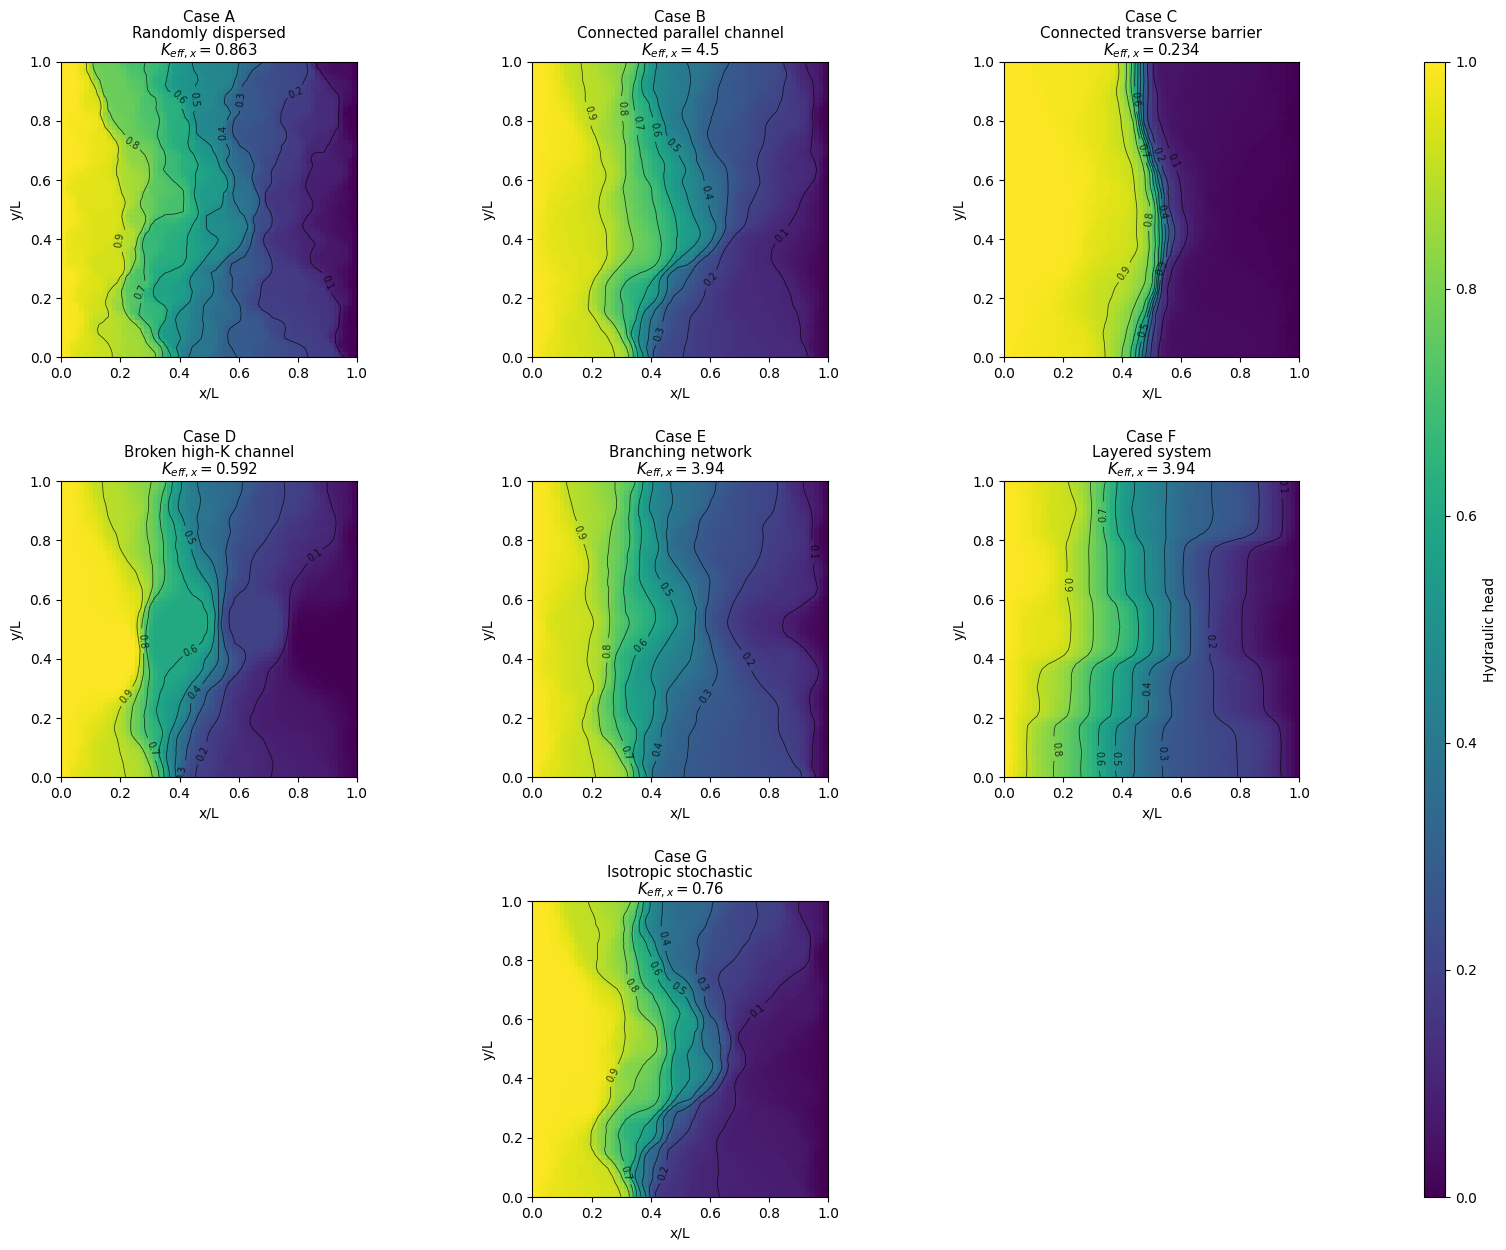

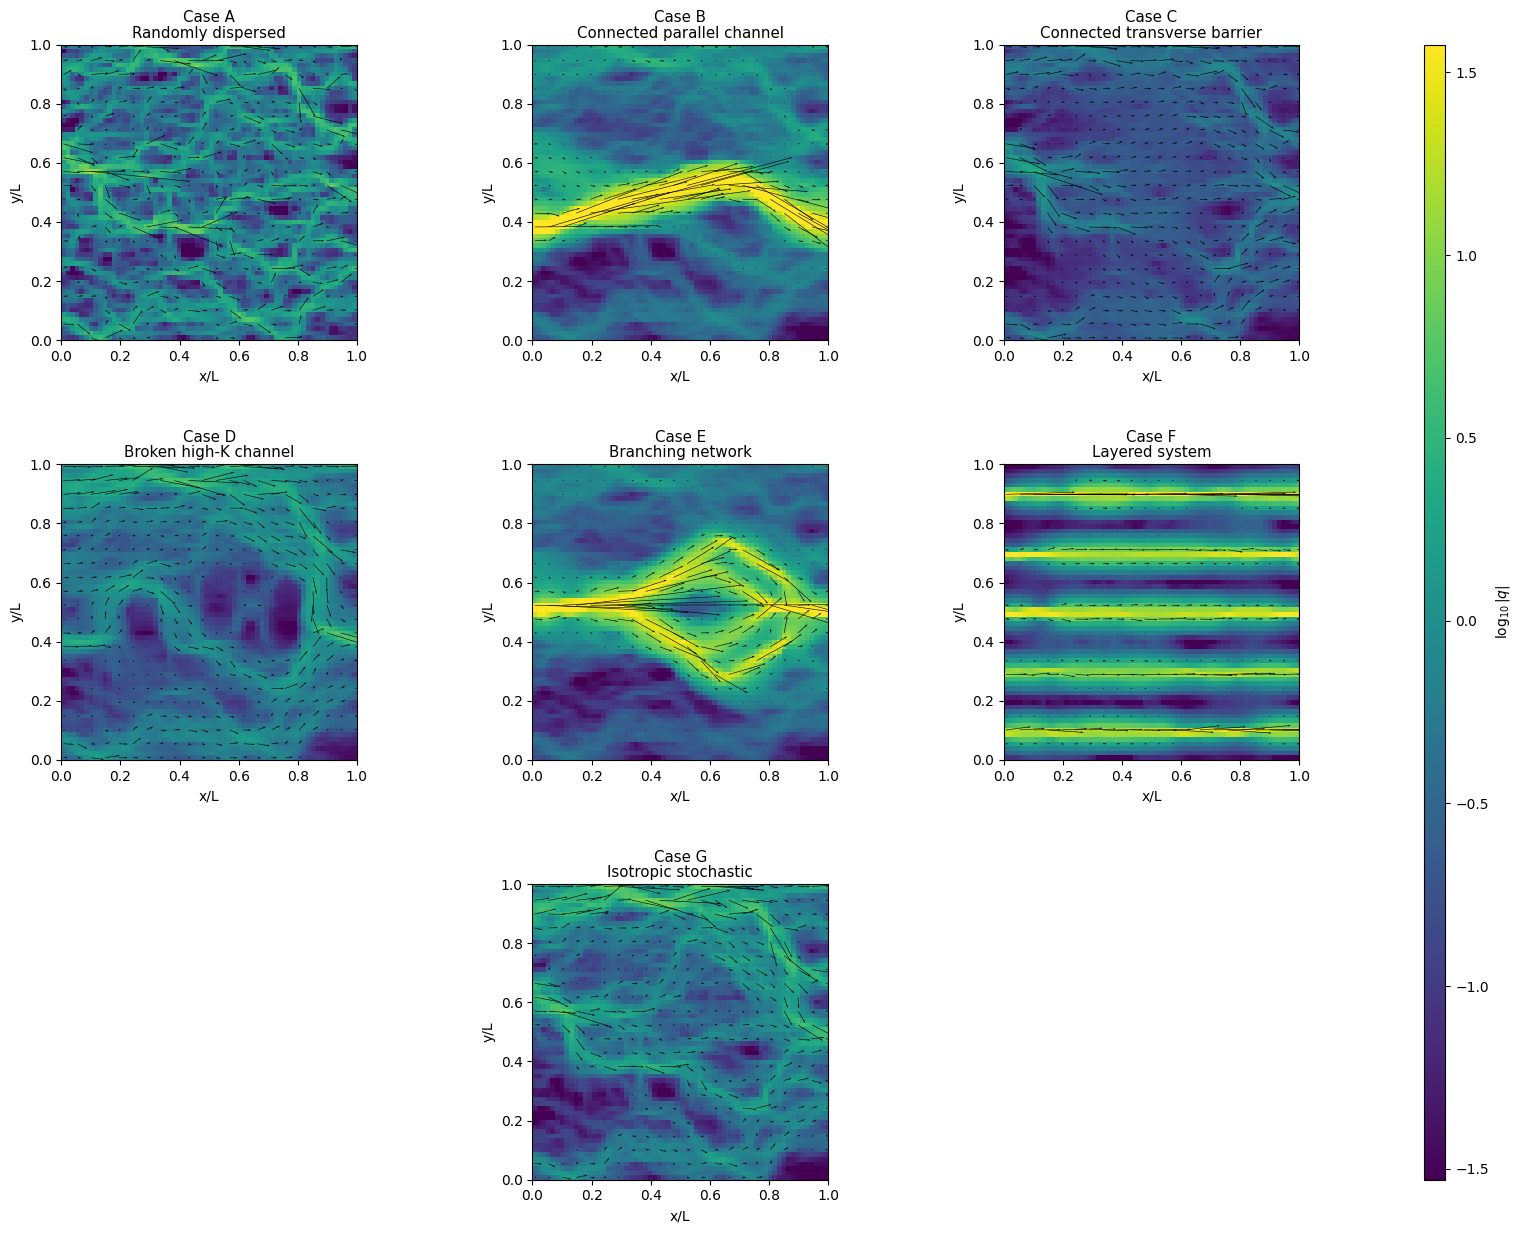

PosixPath('/content/connectivity_seven_case_study/figures/Fig05_flux_fields.png')

In [24]:
# ================================================================
# FIXED FIGURE 4 + FIGURE 5
# Removes the large figure title that overlaps the case titles
# ================================================================

# ------------------------------------------------------------
# Solve / collect example flows
# ------------------------------------------------------------
example_flow = {}

for c in CASE_ORDER:

    fx, fy = directional_keff(
        example_K[c]
    )

    example_flow[c] = (
        fx,
        fy
    )

    print(
        c,
        CASE_NAMES[c],
        "Kx =", fx.Keff,
        "Ky =", fy.Keff,
        "Kx/Ky =", fx.Keff / fy.Keff
    )


# ================================================================
# FIGURE 4 — HYDRAULIC HEAD
# ================================================================

fig, axes, cax = seven_case_layout(
    "",                         # no global title
    with_colorbar=True,
    figsize=(16.5, 13.2)
)

# Hide/remove any suptitle automatically created by the layout function
if getattr(fig, "_suptitle", None) is not None:
    fig._suptitle.set_visible(False)


for ax, c in zip(
    axes,
    CASE_ORDER
):

    fx, _ = example_flow[c]

    # Filled hydraulic-head map
    im = ax.imshow(
        fx.h,
        origin="lower",
        extent=[0, 1, 0, 1],
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    # Black contour lines over the filled map
    cs = ax.contour(
        np.linspace(0, 1, NX),
        np.linspace(0, 1, NY),
        fx.h,
        levels=np.linspace(0.1, 0.9, 9),
        colors="black",
        linewidths=0.55,
        alpha=0.75
    )

    # Contour labels
    ax.clabel(
        cs,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )

    # Compact panel title
    ax.set_title(
        case_panel_title(
            c,
            rf"$K_{{eff,x}}={fx.Keff:.3g}$"
        ),
        fontsize=10.8,
        pad=5,
        linespacing=1.05
    )

    ax.set_xlabel(
        "x/L"
    )

    ax.set_ylabel(
        "y/L"
    )


# Shared colorbar
cb = fig.colorbar(
    im,
    cax=cax
)

cb.set_label(
    "Hydraulic head"
)


# Give the top-row titles some breathing room
fig.subplots_adjust(
    top=0.97
)


plt.show()

savefig(
    fig,
    "Fig04_head_fields.png"
)


# ================================================================
# FIGURE 5 — DARCY FLUX
# ================================================================

# Common log-flux limits across all seven cases
lq = np.concatenate([
    np.log10(
        np.maximum(
            example_flow[c][0].qmag.ravel(),
            1e-30
        )
    )
    for c in CASE_ORDER
])

lo, hi = np.quantile(
    lq,
    [0.01, 0.99]
)


fig, axes, cax = seven_case_layout(
    "",                         # no global title
    with_colorbar=True,
    figsize=(16.5, 13.2)
)

if getattr(fig, "_suptitle", None) is not None:
    fig._suptitle.set_visible(False)


xc = (
    np.arange(NX) + 0.5
) / NX

yc = (
    np.arange(NY) + 0.5
) / NY

Xc, Yc = np.meshgrid(
    xc,
    yc
)

st = max(
    1,
    NX // 18
)


for ax, c in zip(
    axes,
    CASE_ORDER
):

    fx, _ = example_flow[c]

    # Filled map of log10 Darcy-flux magnitude
    im = ax.imshow(
        np.log10(
            np.maximum(
                fx.qmag,
                1e-30
            )
        ),
        origin="lower",
        extent=[0, 1, 0, 1],
        vmin=lo,
        vmax=hi,
        aspect="equal"
    )

    # Darcy-flux vectors
    ax.quiver(
        Xc[::st, ::st],
        Yc[::st, ::st],
        fx.qx_cell[::st, ::st],
        fx.qy_cell[::st, ::st],
        width=0.002
    )

    # Compact title
    ax.set_title(
        case_panel_title(c),
        fontsize=10.8,
        pad=5,
        linespacing=1.05
    )

    ax.set_xlabel(
        "x/L"
    )

    ax.set_ylabel(
        "y/L"
    )


cb = fig.colorbar(
    im,
    cax=cax
)

cb.set_label(
    r"$\log_{10}|q|$"
)


fig.subplots_adjust(
    top=0.97
)


plt.show()

savefig(
    fig,
    "Fig05_flux_fields.png"
)

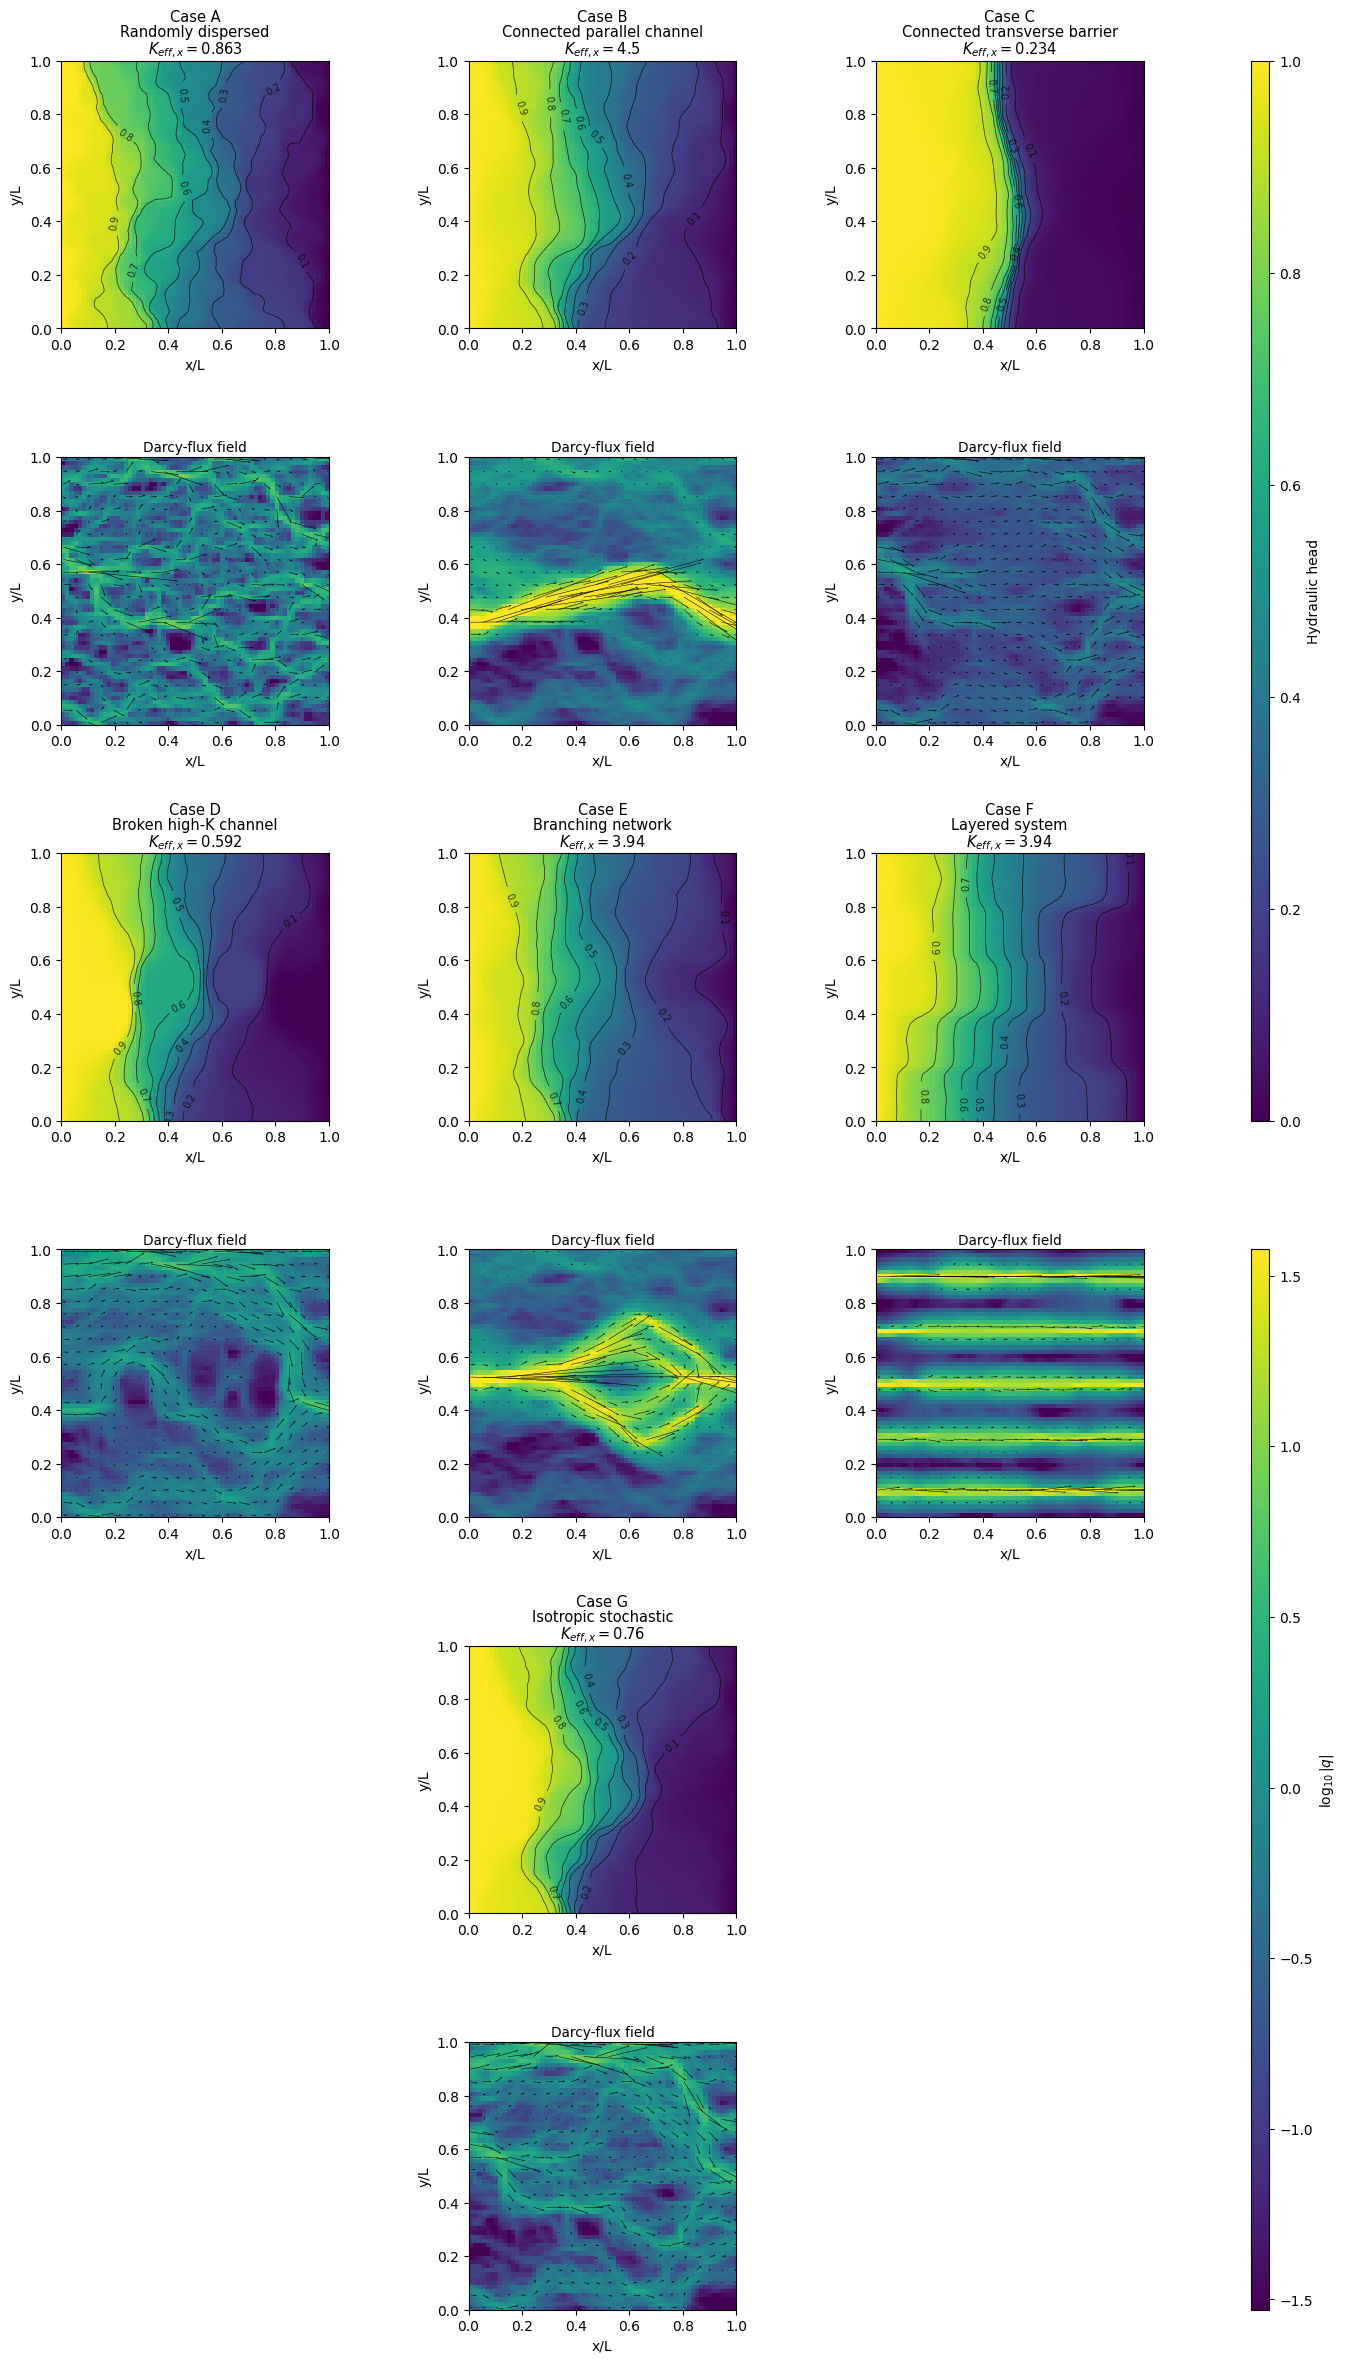

PosixPath('/content/connectivity_seven_case_study/figures/Fig04_05_combined_head_flux_topologies.png')

In [26]:
# ================================================================
# COMBINED HEAD + DARCY-FLUX FIGURE
#
# Row 1: Heads A B C D
# Row 2: Flux  A B C D
# Row 3: Heads   E F G
# Row 4: Flux    E F G
#
# The second group is centered.
# NO overall title is used, preventing overlap with panel subtitles.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ------------------------------------------------------------
# Common coordinates
# ------------------------------------------------------------

xc = (
    np.arange(NX) + 0.5
) / NX

yc = (
    np.arange(NY) + 0.5
) / NY

Xc, Yc = np.meshgrid(
    xc,
    yc
)

xnodes = np.linspace(
    0,
    1,
    NX
)

ynodes = np.linspace(
    0,
    1,
    NY
)


# ------------------------------------------------------------
# Shared flux-color scale
# ------------------------------------------------------------

lq = np.concatenate([
    np.log10(
        np.maximum(
            example_flow[c][0].qmag.ravel(),
            1e-30
        )
    )
    for c in CASE_ORDER
])

lo, hi = np.quantile(
    lq,
    [0.01, 0.99]
)


# Vector spacing
st = max(
    1,
    NX // 18
)


# ------------------------------------------------------------
# Figure / GridSpec
#
# Eight equal plotting columns:
#   A-D each occupy two columns.
#   E-G are centered with a one-column offset.
# Final narrow column contains colorbars.
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(19.0, 18.5)
)

gs = GridSpec(
    nrows=4,
    ncols=9,

    width_ratios=[
        1, 1, 1, 1,
        1, 1, 1, 1,
        0.10
    ],

    height_ratios=[
        1,
        1,
        1,
        1
    ],

    left=0.05,
    right=0.94,
    bottom=0.05,
    top=0.98,
    hspace=0.44,
    wspace=0.36
)


# ================================================================
# Helper — hydraulic-head panel
# ================================================================

def draw_head_panel(
    ax,
    case
):

    fx, _ = example_flow[
        case
    ]

    im = ax.imshow(
        fx.h,
        origin="lower",
        extent=[
            0,
            1,
            0,
            1
        ],
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    cs = ax.contour(
        xnodes,
        ynodes,
        fx.h,

        levels=np.linspace(
            0.1,
            0.9,
            9
        ),

        colors="black",
        linewidths=0.55,
        alpha=0.75
    )

    ax.clabel(
        cs,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )

    ax.set_title(
        case_panel_title(
            case,
            rf"$K_{{eff,x}}={fx.Keff:.3g}$"
        ),
        fontsize=10.1,
        pad=5,
        linespacing=1.0
    )

    ax.set_xlabel(
        "x/L"
    )

    ax.set_ylabel(
        "y/L"
    )

    return im


# ================================================================
# Helper — Darcy-flux panel
# ================================================================

def draw_flux_panel(
    ax,
    case
):

    fx, _ = example_flow[
        case
    ]

    im = ax.imshow(
        np.log10(
            np.maximum(
                fx.qmag,
                1e-30
            )
        ),

        origin="lower",

        extent=[
            0,
            1,
            0,
            1
        ],

        vmin=lo,
        vmax=hi,

        aspect="equal"
    )

    ax.quiver(
        Xc[::st, ::st],
        Yc[::st, ::st],

        fx.qx_cell[::st, ::st],
        fx.qy_cell[::st, ::st],

        width=0.002
    )

    ax.set_title(
        "Darcy-flux field",
        fontsize=9.5,
        pad=4
    )

    ax.set_xlabel(
        "x/L"
    )

    ax.set_ylabel(
        "y/L"
    )

    return im


# ================================================================
# A, B, C, D — FIRST GROUP
# ================================================================

first_group = [
    "A",
    "B",
    "C",
    "D"
]

head_im = None
flux_im = None

top_spans = [
    slice(0,2),
    slice(2,4),
    slice(4,6),
    slice(6,8)
]

for cols, case in zip(
    top_spans,
    first_group
):

    ax_h = fig.add_subplot(
        gs[0, cols]
    )

    head_im = draw_head_panel(
        ax_h,
        case
    )

    ax_q = fig.add_subplot(
        gs[1, cols]
    )

    flux_im = draw_flux_panel(
        ax_q,
        case
    )


# ================================================================
# E, F, G — SECOND GROUP, CENTERED
# ================================================================

second_group = [
    "E",
    "F",
    "G"
]

bottom_spans = [
    slice(1,3),
    slice(3,5),
    slice(5,7)
]

for cols, case in zip(
    bottom_spans,
    second_group
):

    ax_h = fig.add_subplot(
        gs[2, cols]
    )

    head_im = draw_head_panel(
        ax_h,
        case
    )

    ax_q = fig.add_subplot(
        gs[3, cols]
    )

    flux_im = draw_flux_panel(
        ax_q,
        case
    )


# ================================================================
# SHARED HYDRAULIC-HEAD COLORBAR
# ================================================================

cax_head = fig.add_subplot(
    gs[0:2, 8]
)

cb_head = fig.colorbar(
    head_im,
    cax=cax_head
)

cb_head.set_label(
    "Hydraulic head"
)


# ================================================================
# SHARED DARCY-FLUX COLORBAR
# ================================================================

cax_flux = fig.add_subplot(
    gs[2:4, 8]
)

cb_flux = fig.colorbar(
    flux_im,
    cax=cax_flux
)

cb_flux.set_label(
    r"$\log_{10}|q|$"
)


plt.show()


savefig(
    fig,
    "Fig04_05_combined_head_flux_topologies.png"
)


Case A | Randomly dispersed             | Keff = 0.863236 | mass error = 2.694e-13
Case B | Connected parallel channel     | Keff = 4.50339 | mass error = 4.282e-13
Case C | Connected transverse barrier   | Keff = 0.23406 | mass error = 4.271e-13
Case D | Broken high-K channel          | Keff = 0.591889 | mass error = 1.744e-12
Case E | Branching network              | Keff = 3.94285 | mass error = 6.330e-14
Case F | Layered system                 | Keff = 3.9358 | mass error = 1.302e-13
Case G | Isotropic stochastic           | Keff = 0.760285 | mass error = 1.837e-12

Common Darcy-flux color limits:
qvmin = -1.530161
qvmax = 1.576473


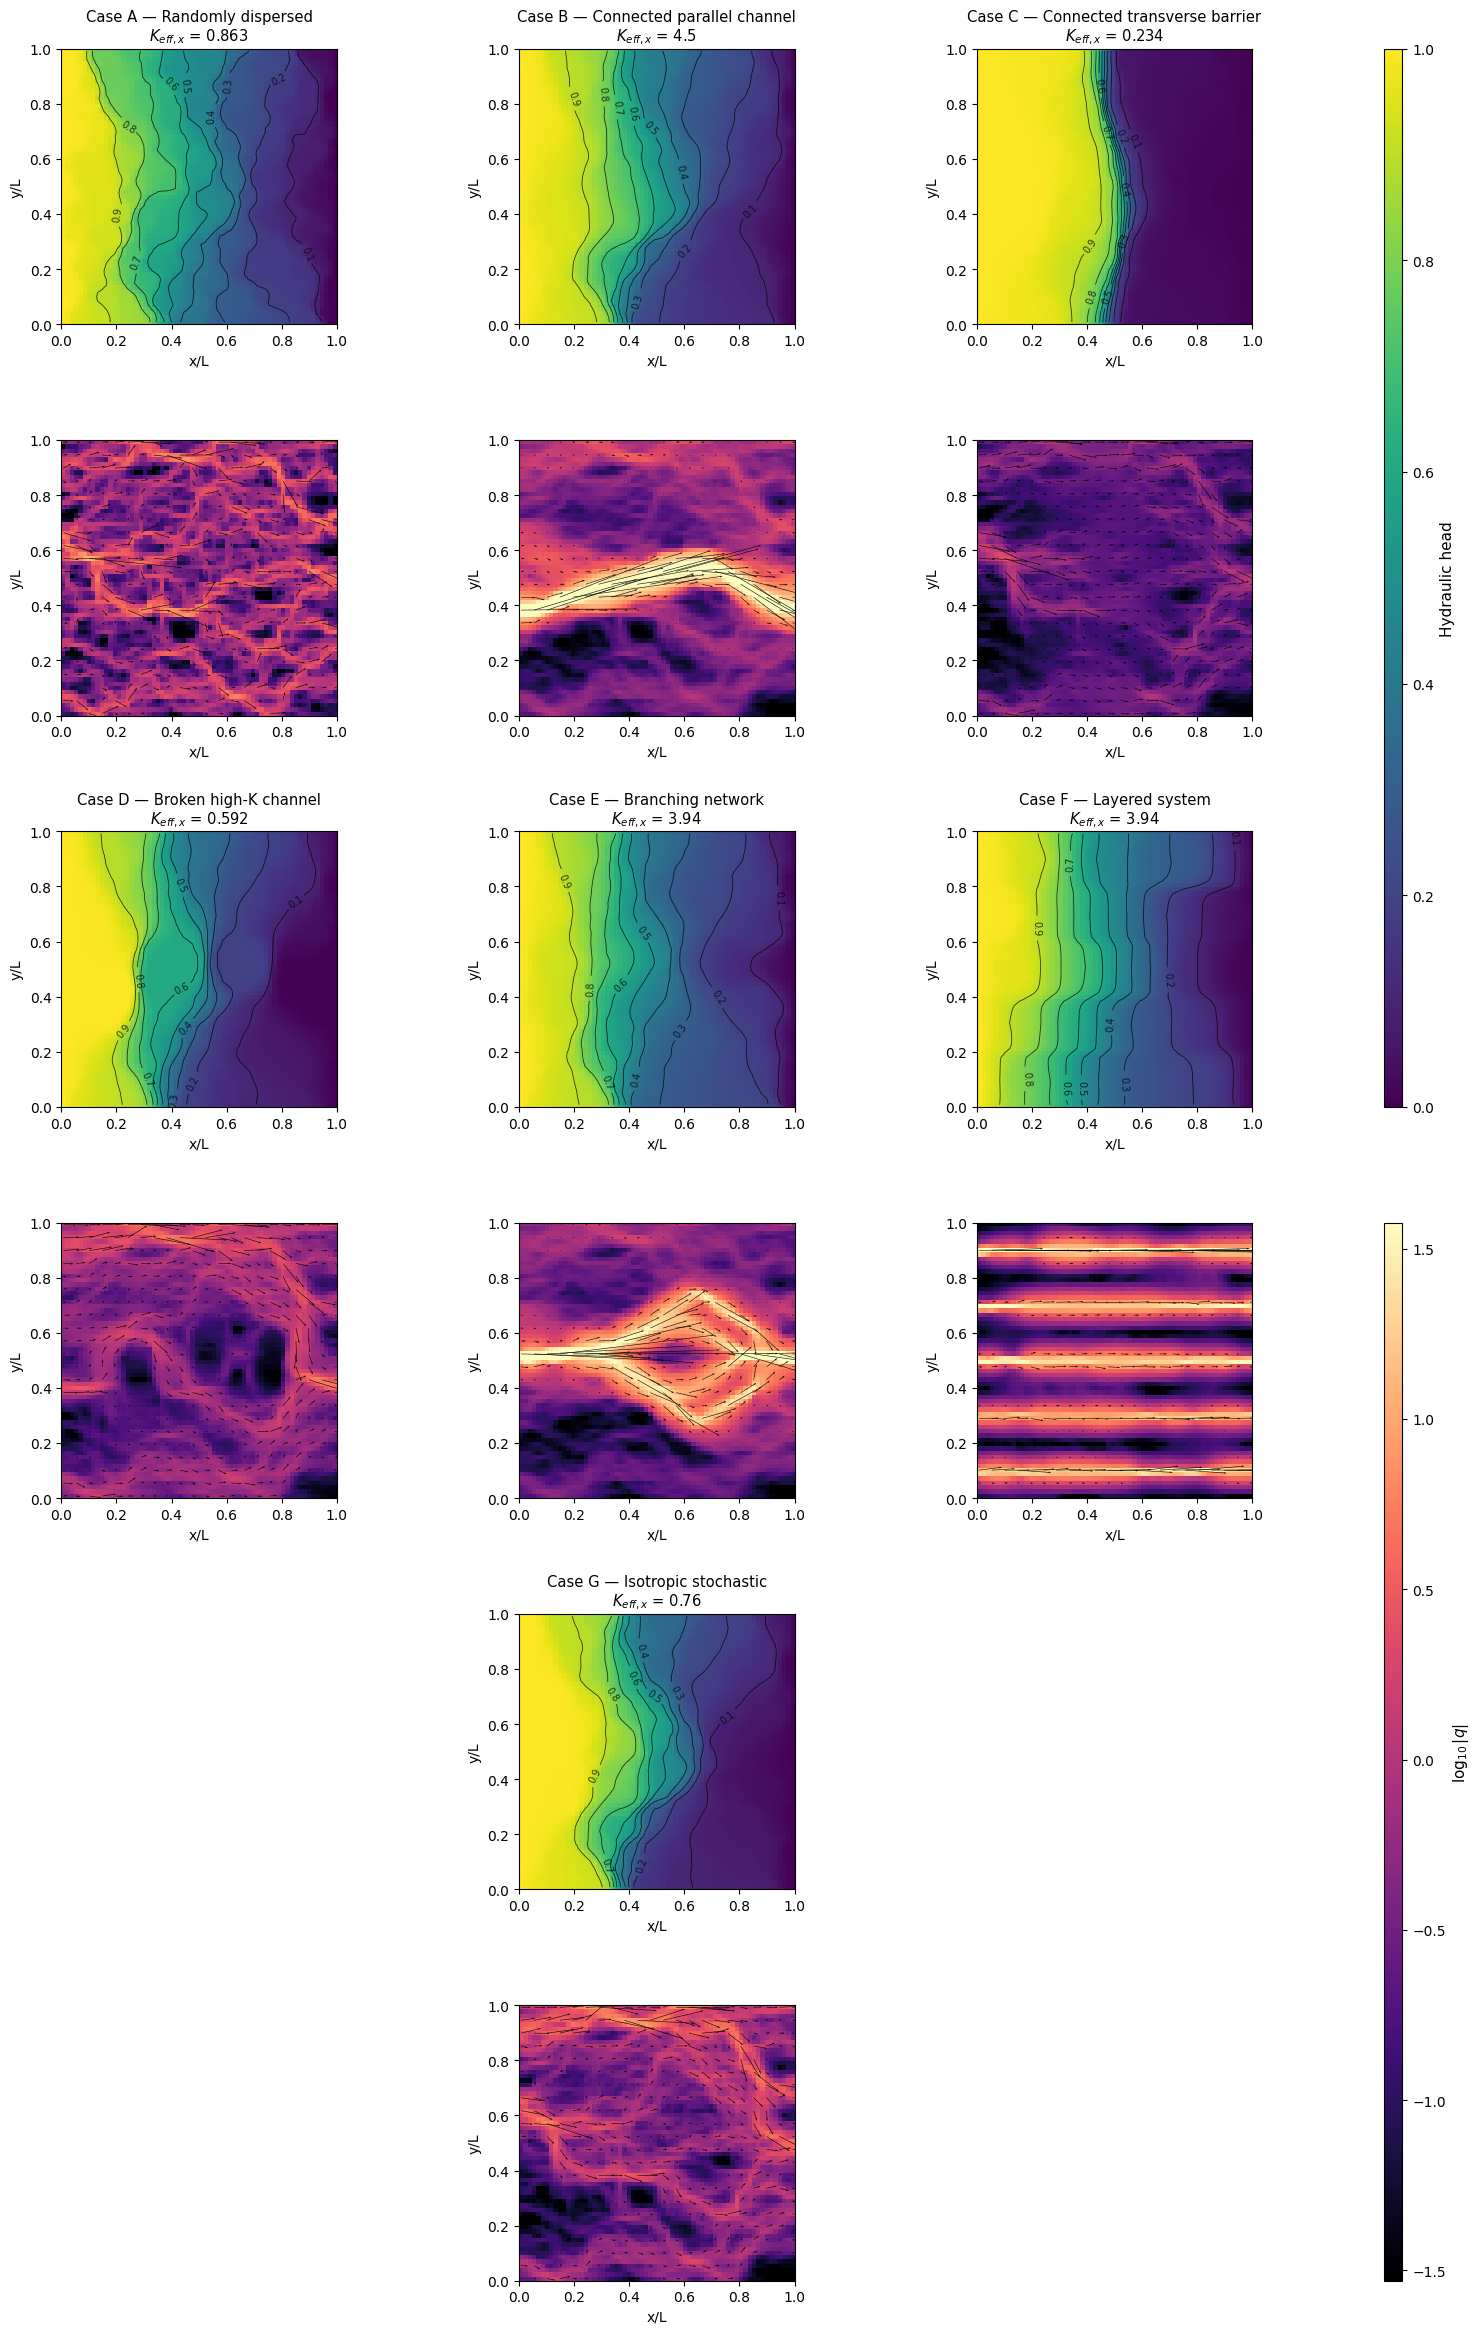

PosixPath('/content/connectivity_seven_case_study/figures/Fig_Combined_Head_Above_Flux_Magma_NoTitle.png')

In [33]:
# ================================================================
# COMBINED HEAD + FLUX FIGURE
#
# Row 1: Heads A B C D
# Row 2: Flux  A B C D
# Row 3: Heads   E F G
# Row 4: Flux    E F G
#
# Flux styling is unchanged:
#   cmap = "magma"
#   common qvmin/qvmax from 1st–99th percentiles
#
# NO overall figure title.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ----------------------------------------------------------------
# Defensive definitions
# ----------------------------------------------------------------
if 'CASE_ORDER' not in globals():
    CASE_ORDER = list("ABCDEFG")

if 'CASE_NAMES' not in globals():
    CASE_NAMES = {
        "A": "Randomly dispersed",
        "B": "Connected parallel channel",
        "C": "Connected transverse barrier",
        "D": "Broken high-K channel",
        "E": "Branching network",
        "F": "Layered system",
        "G": "Isotropic stochastic"
    }

# ----------------------------------------------------------------
# Solve all seven cases using the same original style method
# ----------------------------------------------------------------
example_flow_same_style = {}

for case in CASE_ORDER:

    flow = solve_fvm_x(
        example_K[case],
        Lx,
        Ly,
        H_LEFT,
        H_RIGHT,
        THICKNESS,
        solver=SOLVER
    )

    example_flow_same_style[case] = flow

    print(
        f"Case {case} | "
        f"{CASE_NAMES[case]:30s} | "
        f"Keff = {flow.Keff:.6g} | "
        f"mass error = {flow.mass_error:.3e}"
    )

# ----------------------------------------------------------------
# Coordinates
# ----------------------------------------------------------------
x_centers = (np.arange(NX) + 0.5) * Lx / NX
y_centers = (np.arange(NY) + 0.5) * Ly / NY
Xc, Yc = np.meshgrid(x_centers, y_centers)

x_nodes = np.linspace(0, Lx, NX)
y_nodes = np.linspace(0, Ly, NY)

# ----------------------------------------------------------------
# Common contour levels for hydraulic head
# ----------------------------------------------------------------
head_levels = np.linspace(
    H_RIGHT + 0.1 * (H_LEFT - H_RIGHT),
    H_LEFT  - 0.1 * (H_LEFT - H_RIGHT),
    9
)

# ----------------------------------------------------------------
# Common log-flux color limits across all seven cases
# SAME METHOD as the original code
# ----------------------------------------------------------------
all_logq = np.concatenate([
    np.log10(
        np.maximum(
            example_flow_same_style[case].qmag.ravel(),
            1e-20
        )
    )
    for case in CASE_ORDER
])

qvmin, qvmax = np.quantile(
    all_logq,
    [0.01, 0.99]
)

print("\nCommon Darcy-flux color limits:")
print(f"qvmin = {qvmin:.6f}")
print(f"qvmax = {qvmax:.6f}")

# ----------------------------------------------------------------
# Figure / layout
# ----------------------------------------------------------------
fig = plt.figure(
    figsize=(19.0, 18.5)
)

gs = GridSpec(
    nrows=4,
    ncols=9,
    width_ratios=[
        1, 1, 1, 1,
        1, 1, 1, 1,
        0.10
    ],
    height_ratios=[
        1,
        1,
        1,
        1
    ],
    left=0.05,
    right=0.94,
    bottom=0.05,
    top=0.98,
    wspace=0.36,
    hspace=0.44
)

# ----------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------
step = max(1, NX // 20)

def draw_head_panel(ax, case):
    flow = example_flow_same_style[case]

    im = ax.imshow(
        flow.h,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="viridis",
        vmin=H_RIGHT,
        vmax=H_LEFT,
        aspect="equal"
    )

    cs = ax.contour(
        Xc,
        Yc,
        flow.h,
        levels=head_levels,
        colors="black",
        linewidths=0.6,
        alpha=0.75
    )

    ax.clabel(
        cs,
        fontsize=7,
        fmt="%.1f",
        inline=True
    )

    ax.set_title(
        f"Case {case}\n"
        f"{CASE_NAMES[case]}\n"
        f"$K_{{eff,x}}$ = {flow.Keff:.3g}",
        fontsize=10.1,
        pad=5,
        linespacing=1.0
    )

    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")

    return im


def draw_flux_panel(ax, case):
    flow = example_flow_same_style[case]

    logq = np.log10(
        np.maximum(
            flow.qmag,
            1e-20
        )
    )

    im = ax.imshow(
        logq,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="magma",
        vmin=qvmin,
        vmax=qvmax,
        aspect="equal"
    )

    ax.quiver(
        Xc[::step, ::step],
        Yc[::step, ::step],
        flow.qx_cell[::step, ::step],
        flow.qy_cell[::step, ::step],
        scale=None,
        width=0.002
    )

    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")

    return im


# ----------------------------------------------------------------
# First group: A, B, C, D
# ----------------------------------------------------------------
group1 = [
    "A",
    "B",
    "C",
    "D"
]

top_spans = [
    slice(0,2),
    slice(2,4),
    slice(4,6),
    slice(6,8)
]

head_im = None
flux_im = None

for cols, case in zip(
    top_spans,
    group1
):

    ax_h = fig.add_subplot(
        gs[0, cols]
    )
    head_im = draw_head_panel(
        ax_h,
        case
    )

    ax_q = fig.add_subplot(
        gs[1, cols]
    )
    flux_im = draw_flux_panel(
        ax_q,
        case
    )

# ----------------------------------------------------------------
# Second group: E, F, G — centered
# ----------------------------------------------------------------
group2 = [
    "E",
    "F",
    "G"
]

bottom_spans = [
    slice(1,3),
    slice(3,5),
    slice(5,7)
]

for cols, case in zip(
    bottom_spans,
    group2
):

    ax_h = fig.add_subplot(
        gs[2, cols]
    )
    head_im = draw_head_panel(
        ax_h,
        case
    )

    ax_q = fig.add_subplot(
        gs[3, cols]
    )
    flux_im = draw_flux_panel(
        ax_q,
        case
    )

# ----------------------------------------------------------------
# Shared colorbar for hydraulic head
# ----------------------------------------------------------------
cax_head = fig.add_subplot(
    gs[0:2, 8]
)

cbar_head = fig.colorbar(
    head_im,
    cax=cax_head
)

cbar_head.set_label(
    "Hydraulic head",
    fontsize=11
)

# ----------------------------------------------------------------
# Shared colorbar for Darcy-flux magnitude
# ----------------------------------------------------------------
cax_flux = fig.add_subplot(
    gs[2:4, 8]
)

cbar_flux = fig.colorbar(
    flux_im,
    cax=cax_flux
)

cbar_flux.set_label(
    r"$\log_{10}|q|$",
    fontsize=11
)

plt.show()

savefig(
    fig,
    "Fig_Combined_Head_Above_Flux_Magma_NoTitle.png"
)
